In [1]:
from pathlib import Path
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

In [2]:
PROJECT_ROOT = Path("/home/dev/ESdB-Embeddings-for-Sequential-data-Benchmark")

TASK_MAIN_METRICS = {
    "classification": ["clf", "age"],
    "regression": ["reg", "reg_mentions"],
    "forecasting": ["forecast"],
    "anomaly": ["anomaly"],
}

EPOCH_DIR_RE = re.compile(r"^epoch_(?P<epoch>\d+)(?:\((?P<version>\d+)\))?$")
TARGET_METRIC_RE = re.compile(
    r"^target__(?P<metric>.+?)__.*__validator_seed_(?P<seed>\d+)$"
)

In [3]:
def parse_epoch_dir_name(path):
    match = EPOCH_DIR_RE.match(path.name)
    if match is None:
        return None

    epoch = int(match.group("epoch"))
    version = int(match.group("version") or 0)
    return epoch, version


def latest_epoch_results(reval_dir):
    latest_by_epoch = {}

    for epoch_dir in reval_dir.iterdir():
        parsed = parse_epoch_dir_name(epoch_dir)
        if parsed is None:
            continue

        results_path = epoch_dir / "results.csv"
        if not results_path.exists():
            continue

        epoch, version = parsed
        previous = latest_by_epoch.get(epoch)
        if previous is None or version > previous[0]:
            latest_by_epoch[epoch] = (version, results_path)

    return [
        latest_by_epoch[epoch][1]
        for epoch in sorted(latest_by_epoch)
    ]


def task_name_from_dir(task_dir):
    return task_dir.name.removeprefix("best_")


def read_results_values(results_path, value_col="mean"):
    df = pd.read_csv(results_path, index_col=0)
    if value_col not in df.columns:
        value_col = df.columns[0]

    return pd.to_numeric(df[value_col], errors="coerce")


def choose_main_metric(metric_names, task_name, main_metric_map=None):
    main_metric_map = main_metric_map or TASK_MAIN_METRICS
    candidates = main_metric_map.get(task_name, [])

    for metric_name in candidates:
        if metric_name in metric_names:
            return metric_name

    return None


def parse_results_csv(results_path, task_name, value_col="mean", main_metric_map=None):
    values = read_results_values(results_path, value_col=value_col)
    epoch, version = parse_epoch_dir_name(results_path.parent)
    metrics = {}

    row = {
        "task": task_name,
        "epoch": epoch,
        "epoch_version": version,
        "epoch_dir": results_path.parent.name,
        "results_path": str(results_path),
    }

    for name, value in values.items():
        metric_match = TARGET_METRIC_RE.match(name)
        if metric_match is not None:
            metric_name = metric_match.group("metric")
            seed = int(metric_match.group("seed")) + 1
            metrics.setdefault(metric_name, {})[seed] = value
            continue

        if "loss" in name:
            row[name] = value

    for metric_name, seed_values in sorted(metrics.items()):
        metric_series = pd.Series(seed_values, dtype="float64").sort_index()
        for seed, value in metric_series.items():
            row[f"{metric_name}_seed{seed}"] = value

        row[f"{metric_name}_mean"] = metric_series.mean()
        row[f"{metric_name}_max"] = metric_series.max()

    main_metric = choose_main_metric(metrics.keys(), task_name, main_metric_map)
    row["main_metric"] = main_metric
    if main_metric is not None:
        main_series = pd.Series(metrics[main_metric], dtype="float64").sort_index()
        for seed in range(1, 4):
            row[f"main_seed{seed}"] = main_series.get(seed)

        row["main_mean"] = main_series.mean()
        row["main_max"] = main_series.max()

    return row


def build_task_df(task_dir, reval_name="reval_sample", value_col="mean", main_metric_map=None):
    task_dir = Path(task_dir)
    reval_dir = task_dir / reval_name
    task_name = task_name_from_dir(task_dir)

    if not reval_dir.exists():
        return pd.DataFrame()

    rows = [
        parse_results_csv(
            results_path,
            task_name=task_name,
            value_col=value_col,
            main_metric_map=main_metric_map,
        )
        for results_path in latest_epoch_results(reval_dir)
    ]

    return pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)


def build_task_dfs(tests_dir, reval_name="reval_sample", value_col="mean", main_metric_map=None):
    tests_dir = Path(tests_dir)
    task_dfs = {}

    for task_dir in sorted(tests_dir.glob("best_*")):
        if not task_dir.is_dir():
            continue

        task_name = task_name_from_dir(task_dir)
        task_dfs[task_name] = build_task_df(
            task_dir,
            reval_name=reval_name,
            value_col=value_col,
            main_metric_map=main_metric_map,
        )

    return task_dfs



In [6]:
REVAL_NAME = "revalidation"
DATASET = "30music"
METHOD = "jepa_optuna"

TESTS_DIR = PROJECT_ROOT / "log" / "full" / DATASET / METHOD / "tests"

In [7]:
task_dfs = build_task_dfs(TESTS_DIR, reval_name=REVAL_NAME)

classification_df = task_dfs.get("classification", pd.DataFrame())
regression_df = task_dfs.get("regression", pd.DataFrame())
forecasting_df = task_dfs.get("forecasting", pd.DataFrame())
anomaly_df = task_dfs.get("anomaly", pd.DataFrame())

{task: df.shape for task, df in task_dfs.items()}


{'anomaly': (21, 37),
 'classification': (21, 37),
 'forecasting': (21, 37),
 'regression': (21, 37)}

In [8]:
classification_df.columns

Index(['task', 'epoch', 'epoch_version', 'epoch_dir', 'results_path',
       'train_jepa_loss', 'train_loss', 'train_val_jepa_loss',
       'train_val_loss', 'test_jepa_loss', 'test_loss', 'anomaly_seed1',
       'anomaly_seed2', 'anomaly_seed3', 'anomaly_mean', 'anomaly_max',
       'clf_seed1', 'clf_seed2', 'clf_seed3', 'clf_mean', 'clf_max',
       'forecast_seed1', 'forecast_seed2', 'forecast_seed3', 'forecast_mean',
       'forecast_max', 'reg_seed1', 'reg_seed2', 'reg_seed3', 'reg_mean',
       'reg_max', 'main_metric', 'main_seed1', 'main_seed2', 'main_seed3',
       'main_mean', 'main_max'],
      dtype='object')

In [9]:
clean_cols = {
    "epoch": "epoch",
    "train_val_loss": "loss",
    "reg_mean": "reg",
    # "reg_mentions_mean": "reg",
    "clf_mean": "clf",
    "anomaly_mean": "anom",
    "forecast_mean": "forecast"
}
# clean_cols = {
#     "train_val_loss": "loss",
#     "main_mean": "clf"
# }
clean_clf = classification_df[clean_cols.keys()].rename(columns=clean_cols).set_index("epoch")
clean_reg = regression_df[clean_cols.keys()].rename(columns=clean_cols).set_index("epoch")
clean_forecast = forecasting_df[clean_cols.keys()].rename(columns=clean_cols).set_index("epoch")
clean_anom = anomaly_df[clean_cols.keys()].rename(columns=clean_cols).set_index("epoch")


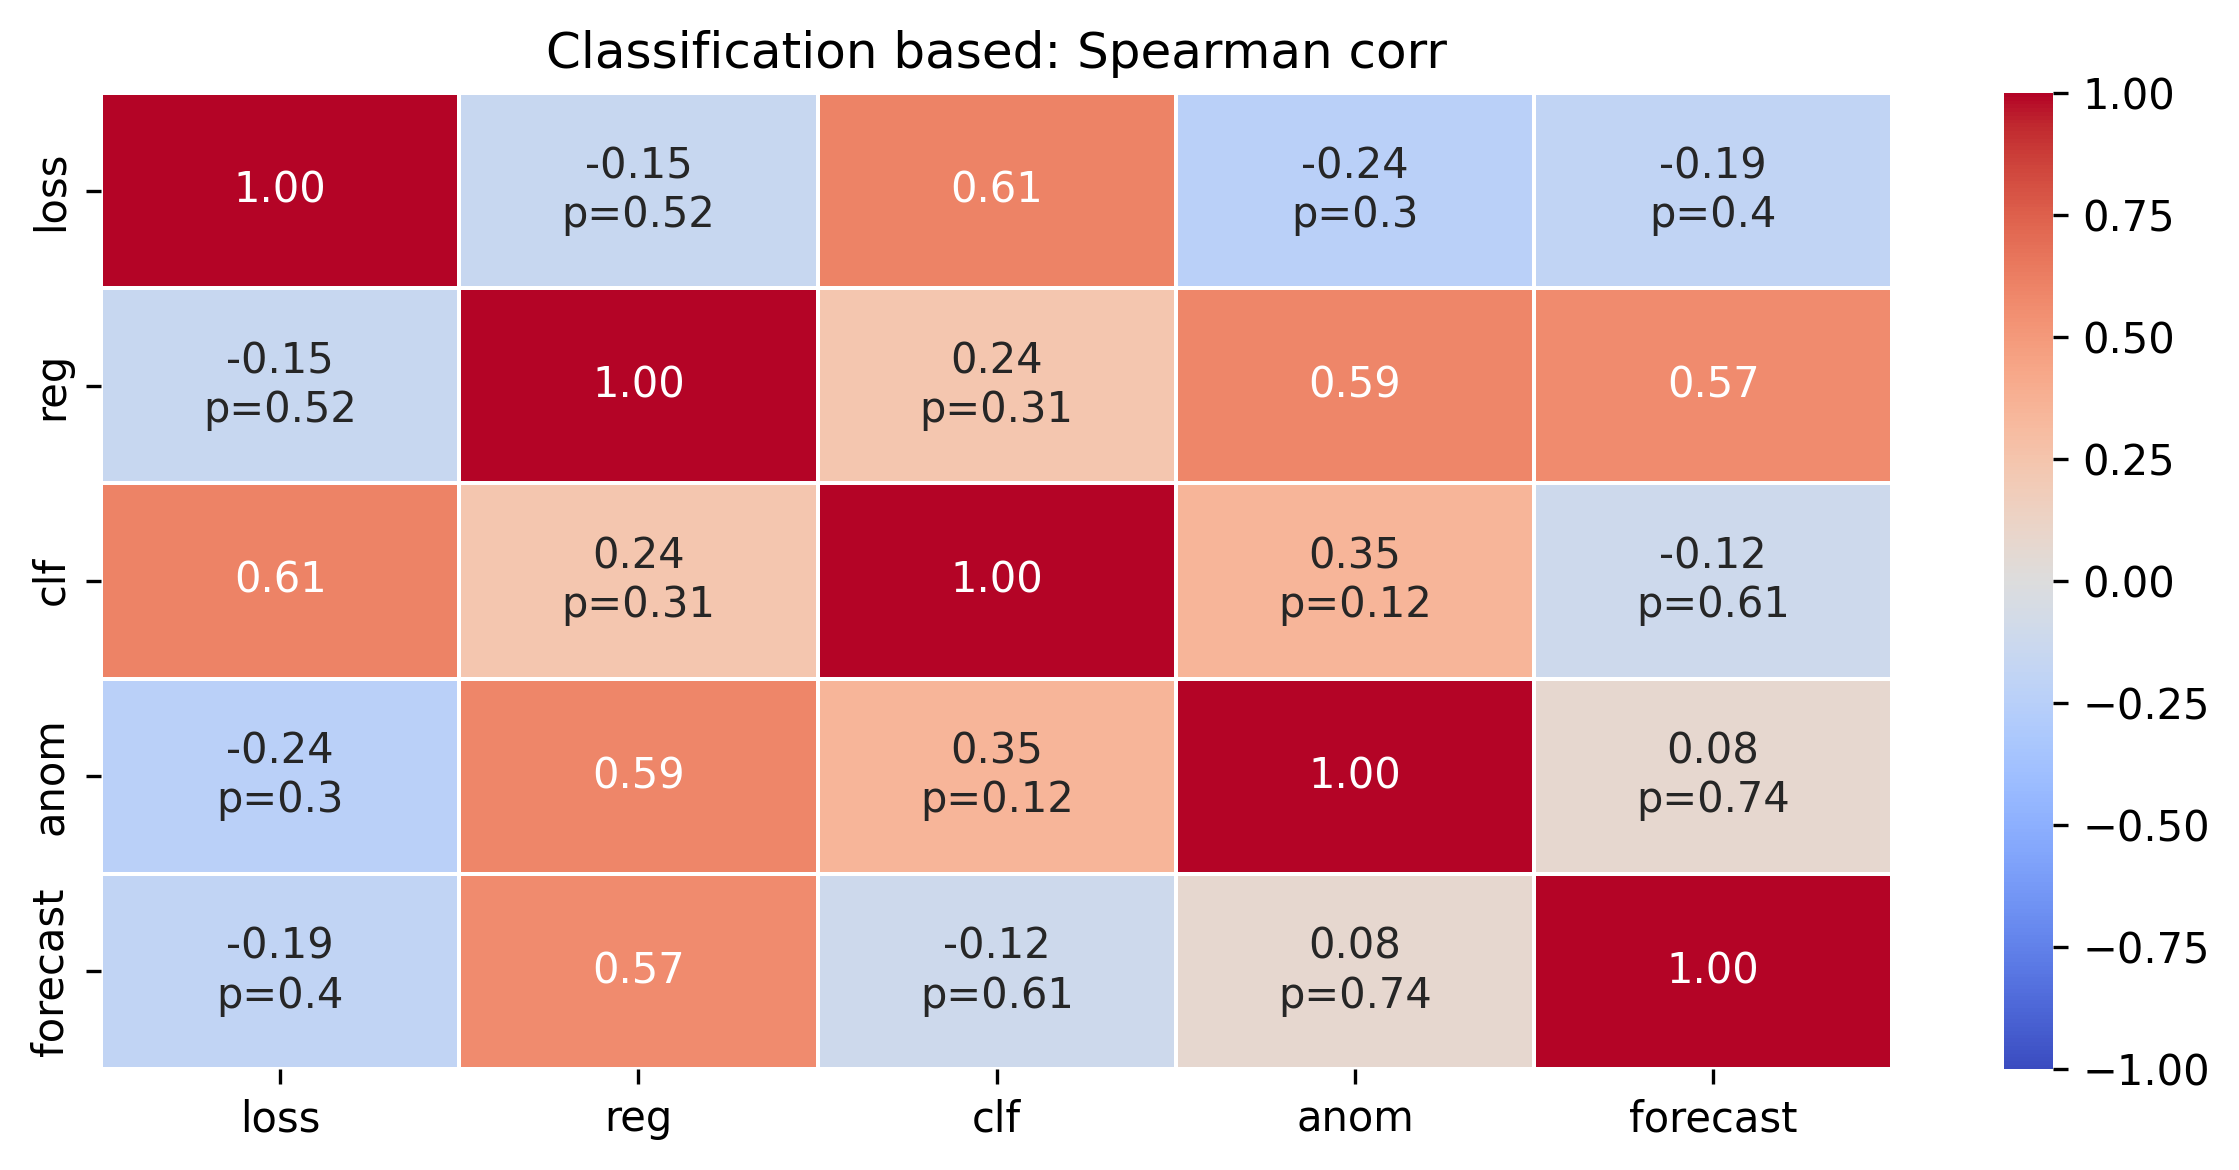

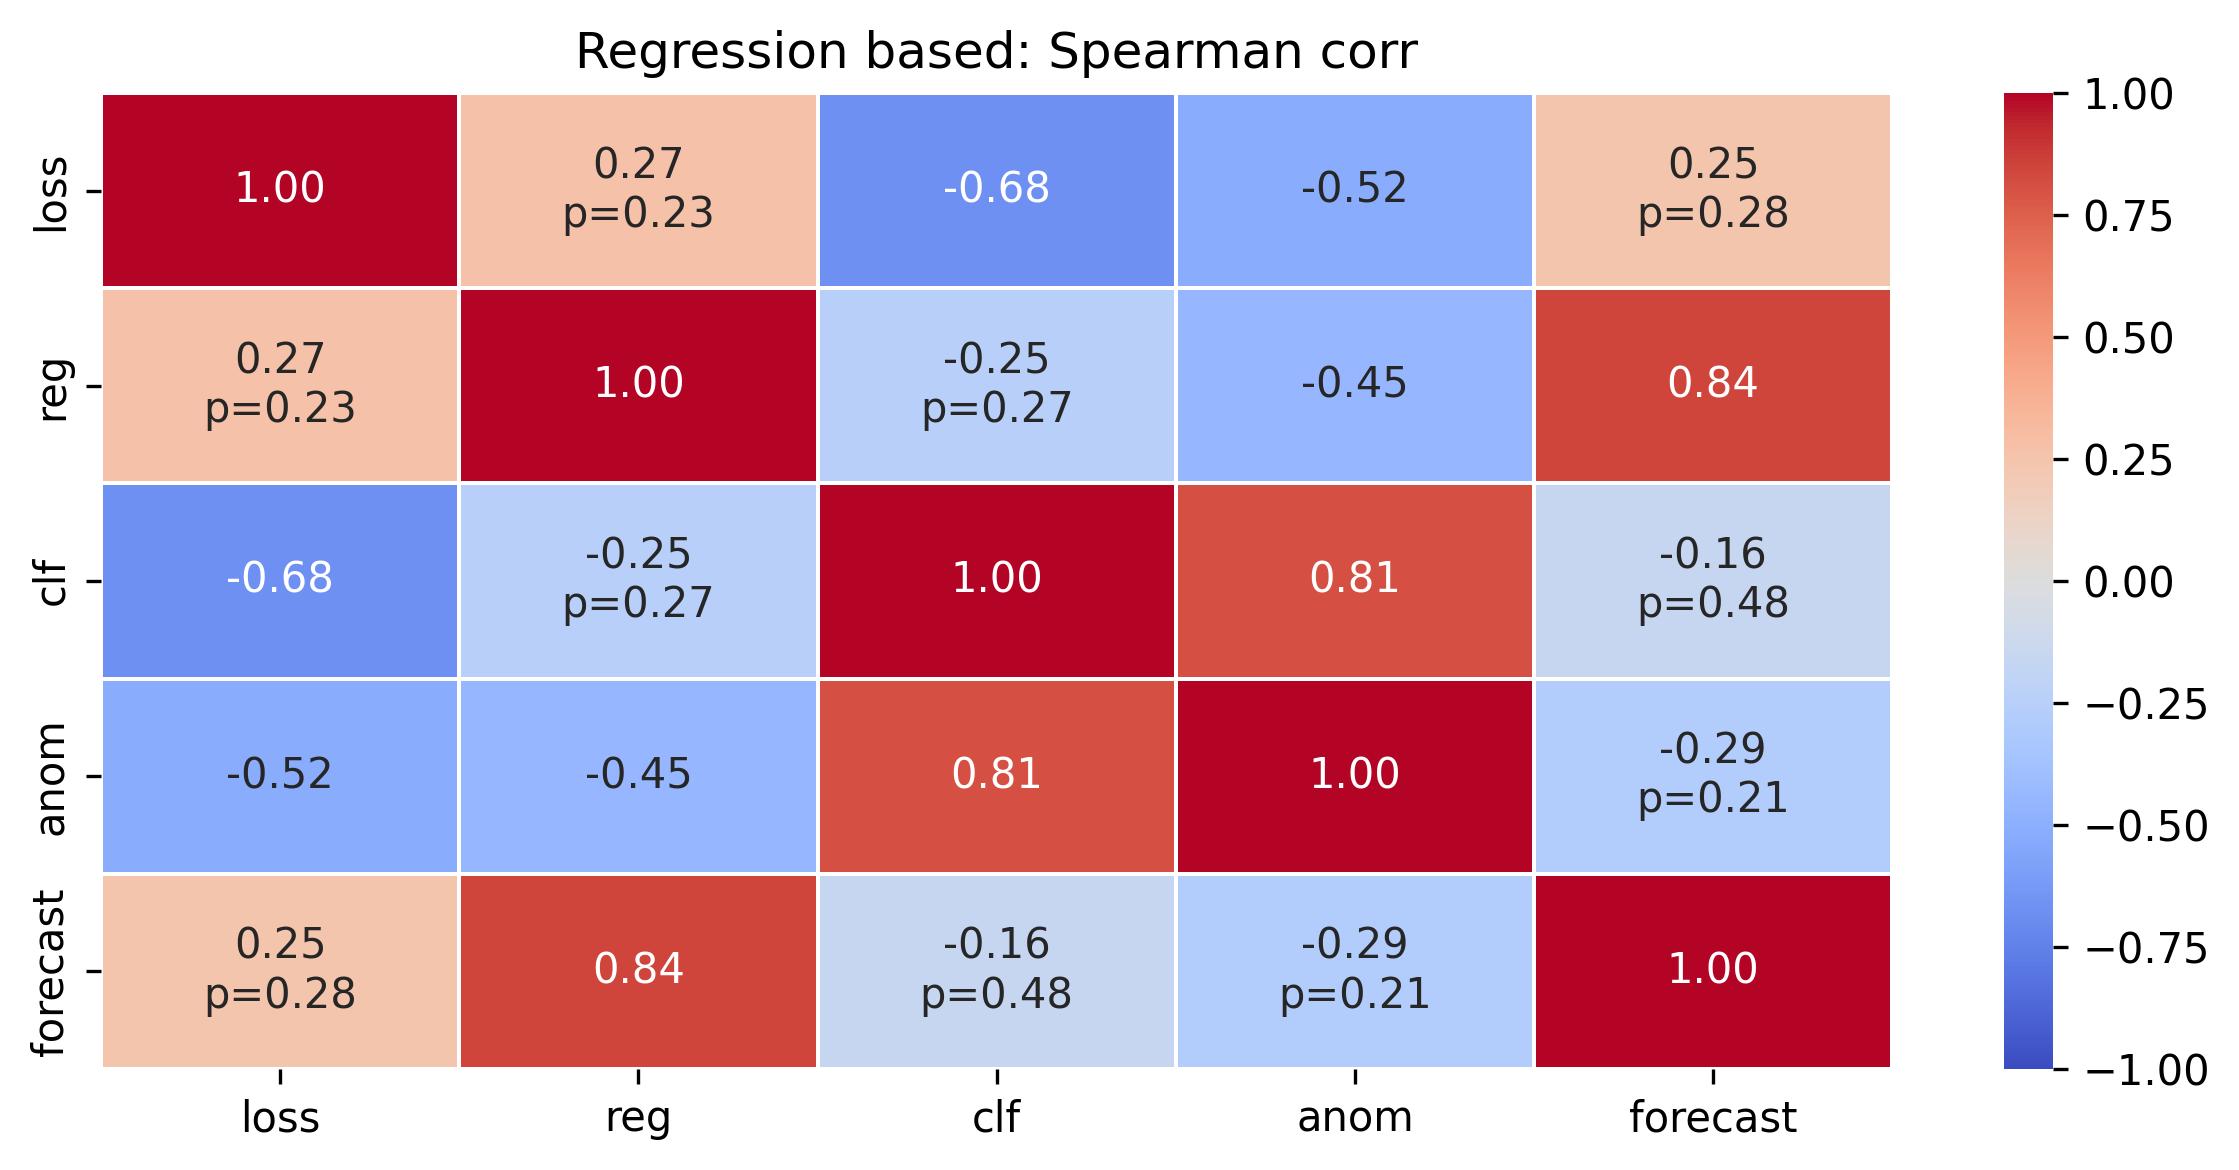

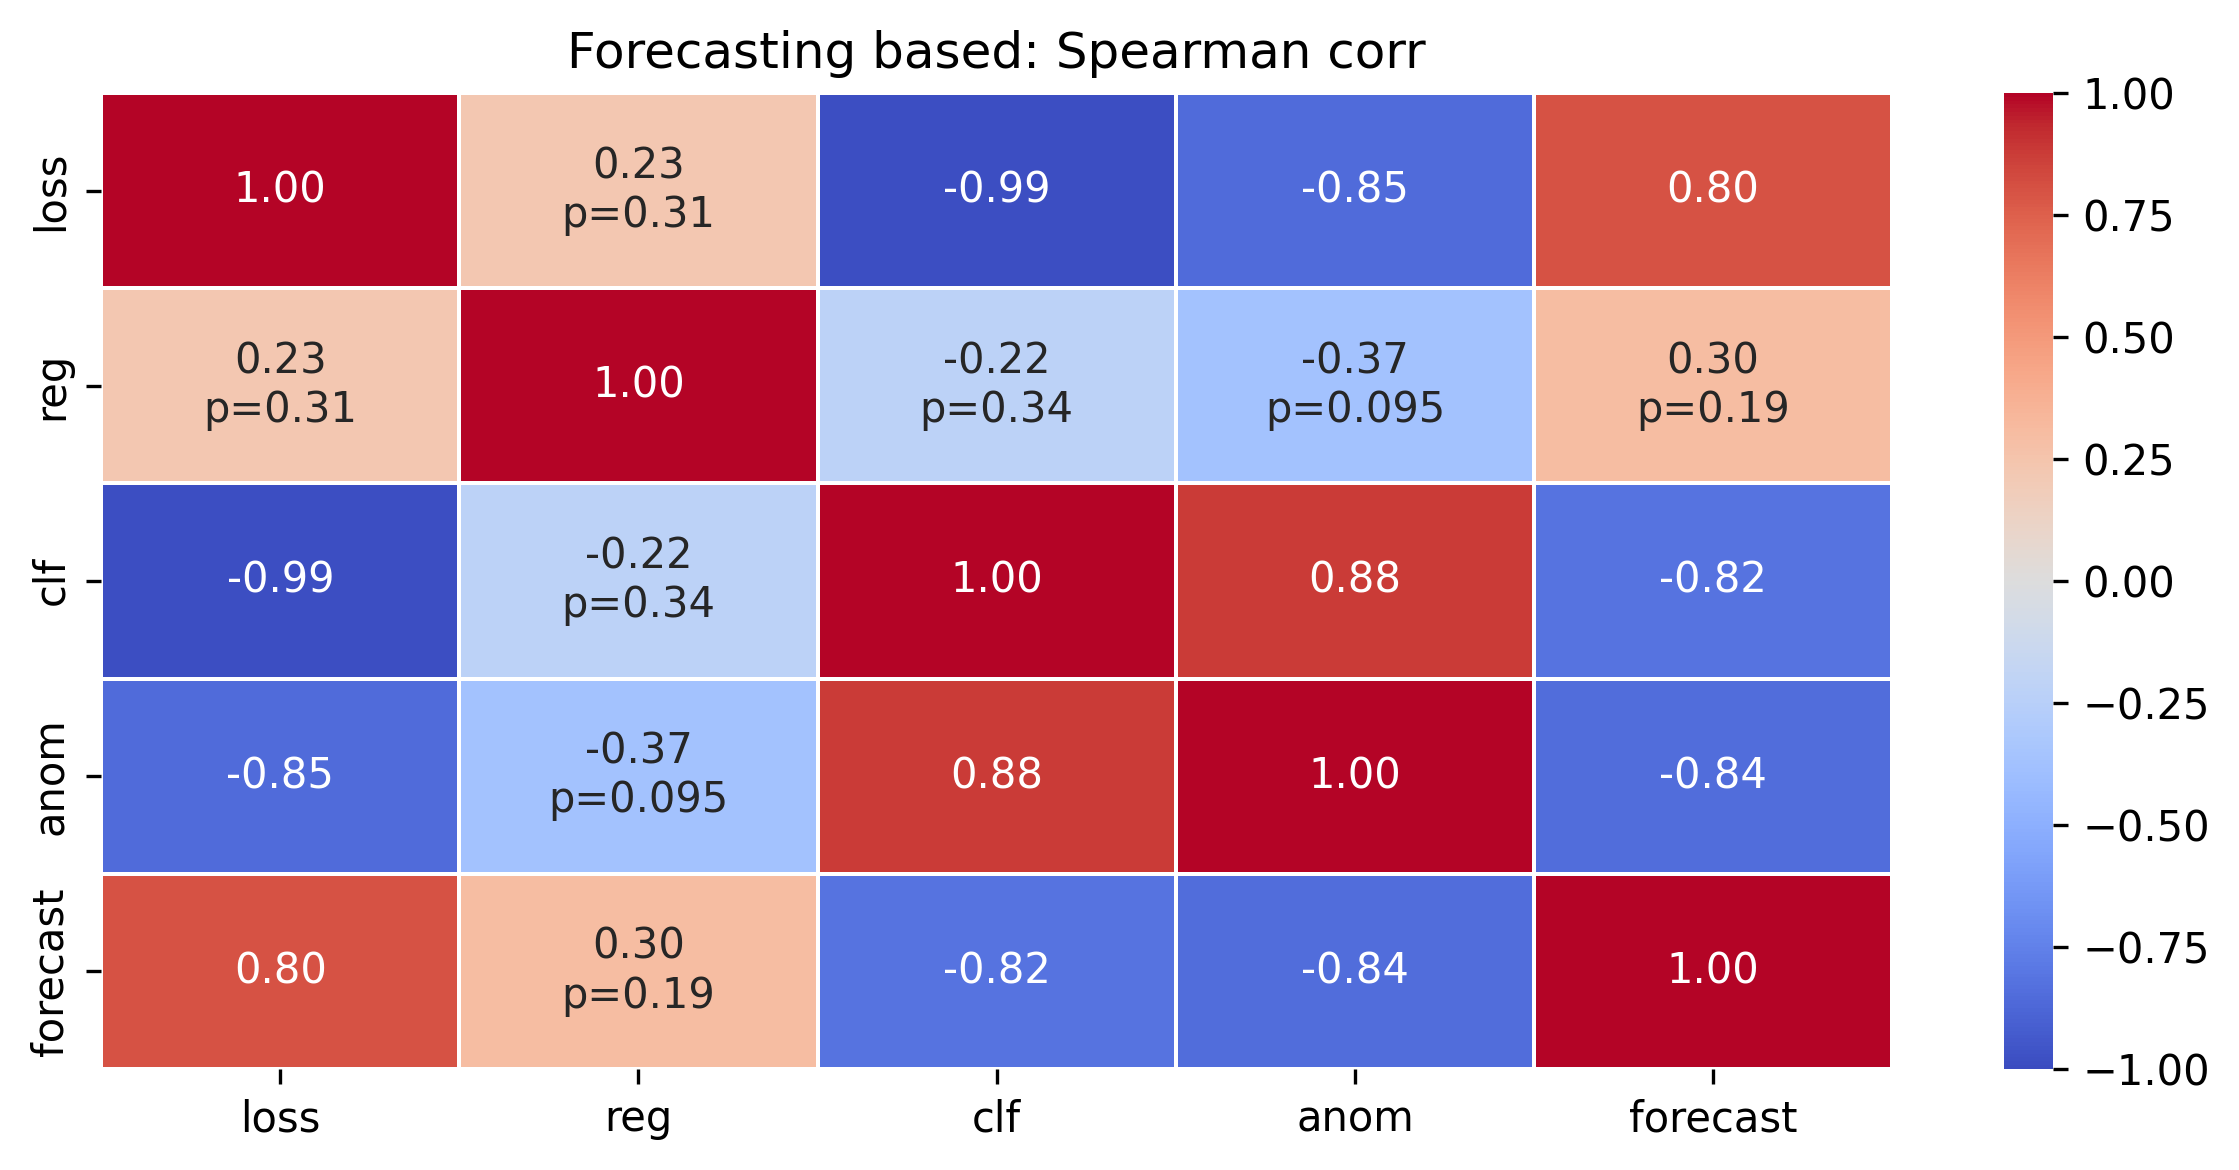

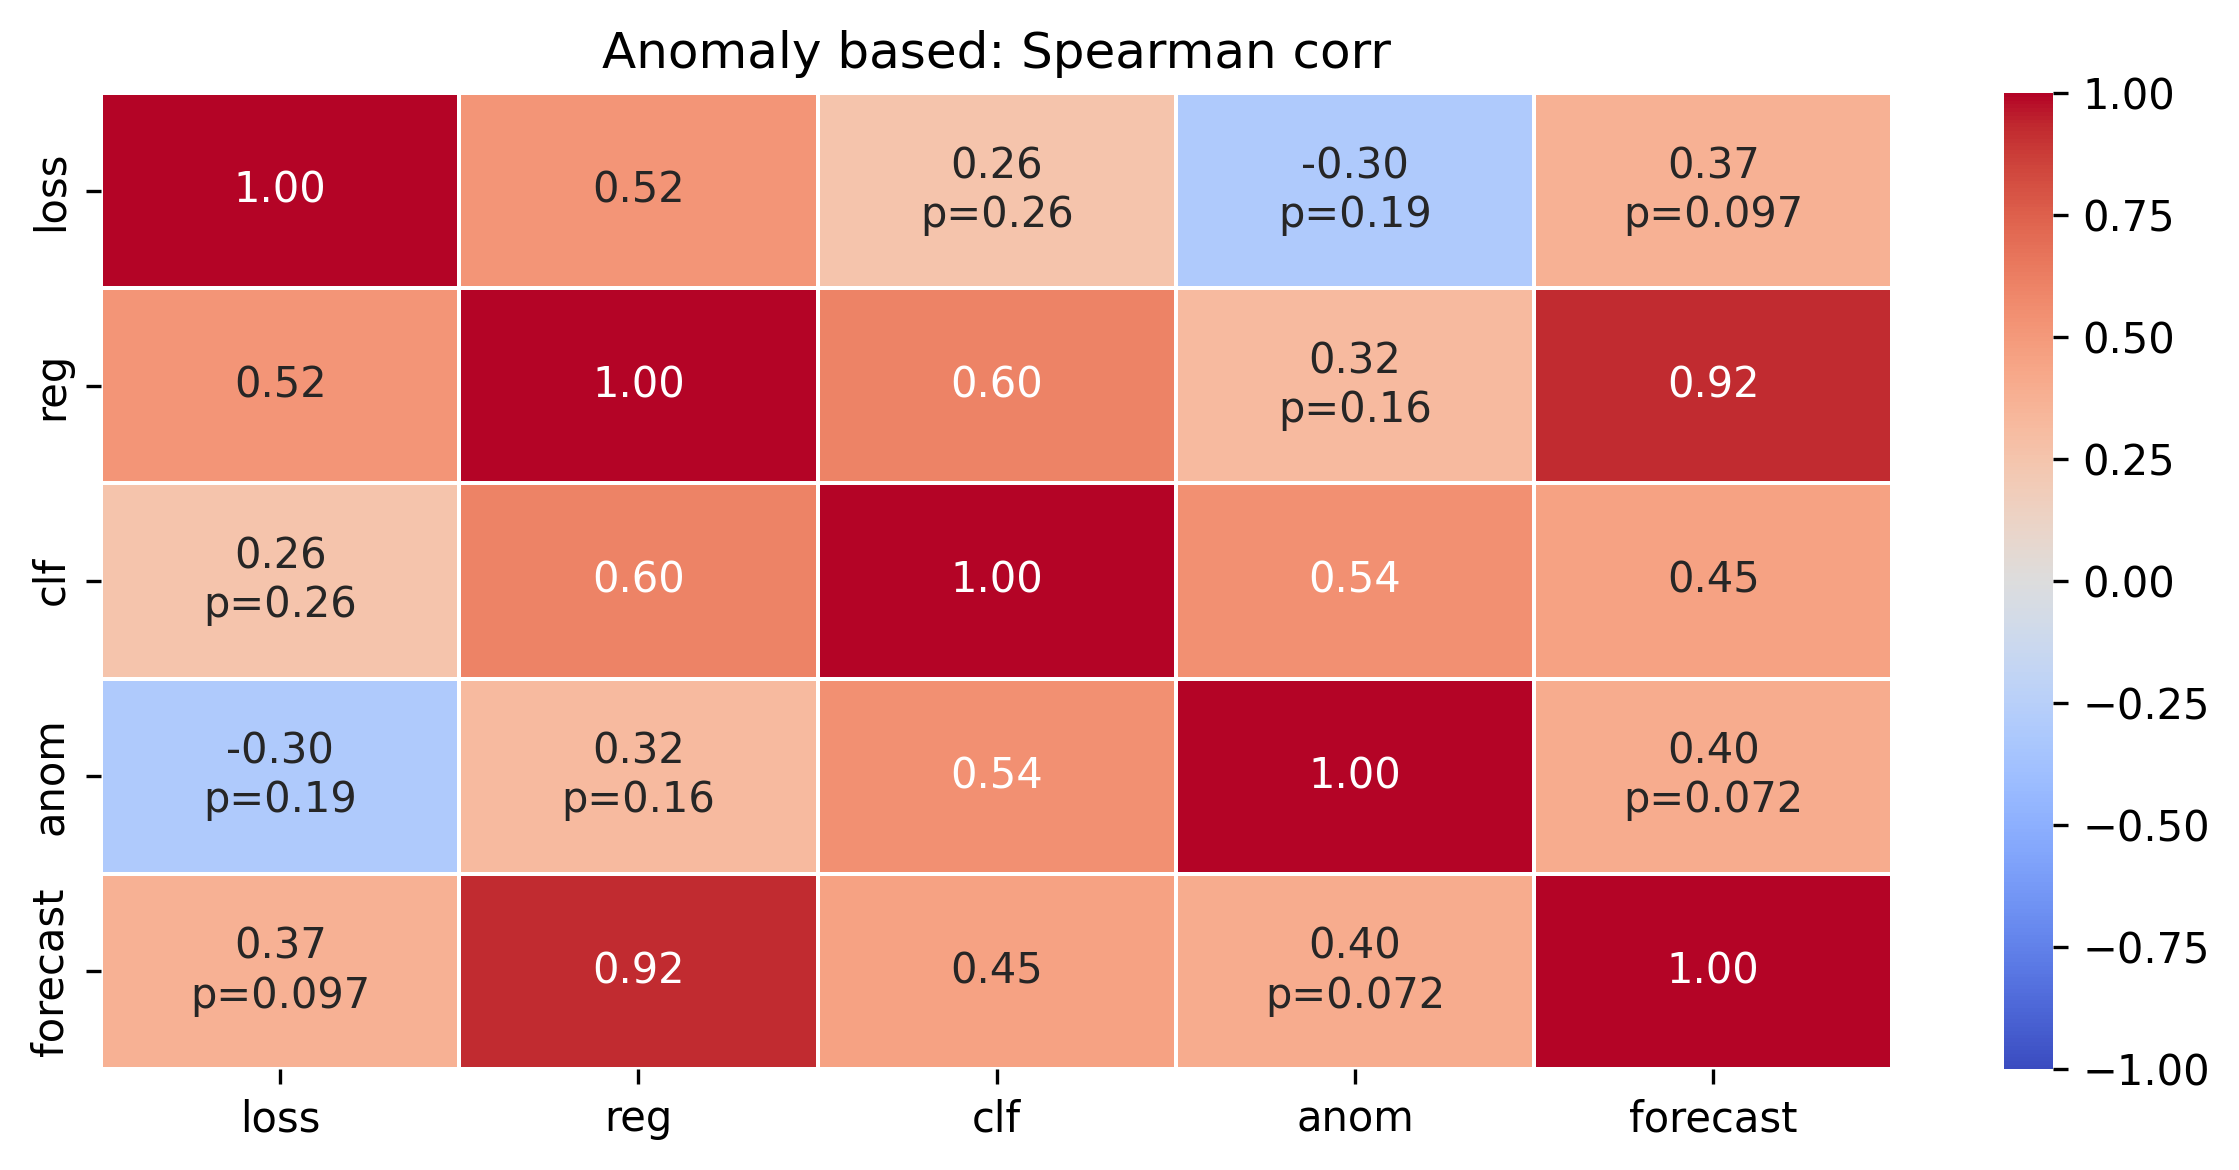

In [ ]:
P_VALUE_WARN_THRESHOLD = 0.05


def corr_and_pvalue_matrices(df, method):
    corr_fn = spearmanr if method == "spearman" else pearsonr
    cols = df.columns
    corr = pd.DataFrame(1.0, index=cols, columns=cols)
    p_values = pd.DataFrame(0.0, index=cols, columns=cols)

    for left_idx, left_col in enumerate(cols):
        for right_col in cols[left_idx + 1:]:
            pair = df[[left_col, right_col]].dropna()
            corr_value, p_value = corr_fn(pair[left_col], pair[right_col])
            corr.loc[left_col, right_col] = corr_value
            corr.loc[right_col, left_col] = corr_value
            p_values.loc[left_col, right_col] = p_value
            p_values.loc[right_col, left_col] = p_value

    return corr, p_values


def corr_heatmap_labels(corr, p_values, p_value_threshold):
    labels = corr.map(lambda x: f"{x:.2f}")
    show_p_value = p_values >= p_value_threshold
    show_p_value.values[range(len(show_p_value)), range(len(show_p_value))] = False

    return labels.mask(
        show_p_value,
        labels + "\np=" + p_values.map(lambda x: f"{x:.2g}"),
    )


def plot_corr_heatmaps(clean_dfs, method="spearman", p_value_threshold=P_VALUE_WARN_THRESHOLD):
    if method not in {"spearman", "pearson"}:
        raise ValueError('method must be "spearman" or "pearson"')

    for title, df in clean_dfs.items():
        corr, p_values = corr_and_pvalue_matrices(df, method)
        labels = corr_heatmap_labels(corr, p_values, p_value_threshold)

        plt.figure(figsize=(8, 4), dpi=300)
        ax = sns.heatmap(
            corr,
            annot=labels,
            fmt="",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            cbar=True,
            linewidths=0.5,
            linecolor="white",
        )
        ax.set_title(f"{title}: {method.capitalize()} corr")
        plt.tight_layout()
        plt.show()

clean_dfs = {
    "Classification based": clean_clf,
    "Regression based": clean_reg,
    "Forecasting based": clean_forecast,
    "Anomaly based": clean_anom,
}

plot_corr_heatmaps(clean_dfs, method="spearman")

In [14]:
def plot_epoch_metric_points(clean_dfs, epoch_name="epoch"):
    for title, df in clean_dfs.items():
        plot_df = (
            df
            .rename_axis(epoch_name)
            .reset_index()
            .melt(id_vars=epoch_name, var_name="metric", value_name="value")
            .dropna()
        )

        plt.figure(figsize=(9, 5), dpi=300)
        ax = sns.lineplot(
            data=plot_df,
            x=epoch_name,
            y="value",
            hue="metric",
            style="metric",
            markers=True,
            dashes=False,
            linewidth=2,
            markersize=7,
        )
        ax.set_title(f"{title}: loss and metrics by epoch")
        ax.set_xlabel(epoch_name)
        ax.set_ylabel("value")
        ax.grid(True, alpha=0.25)
        ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")
        sns.despine()
        plt.tight_layout()
        plt.show()


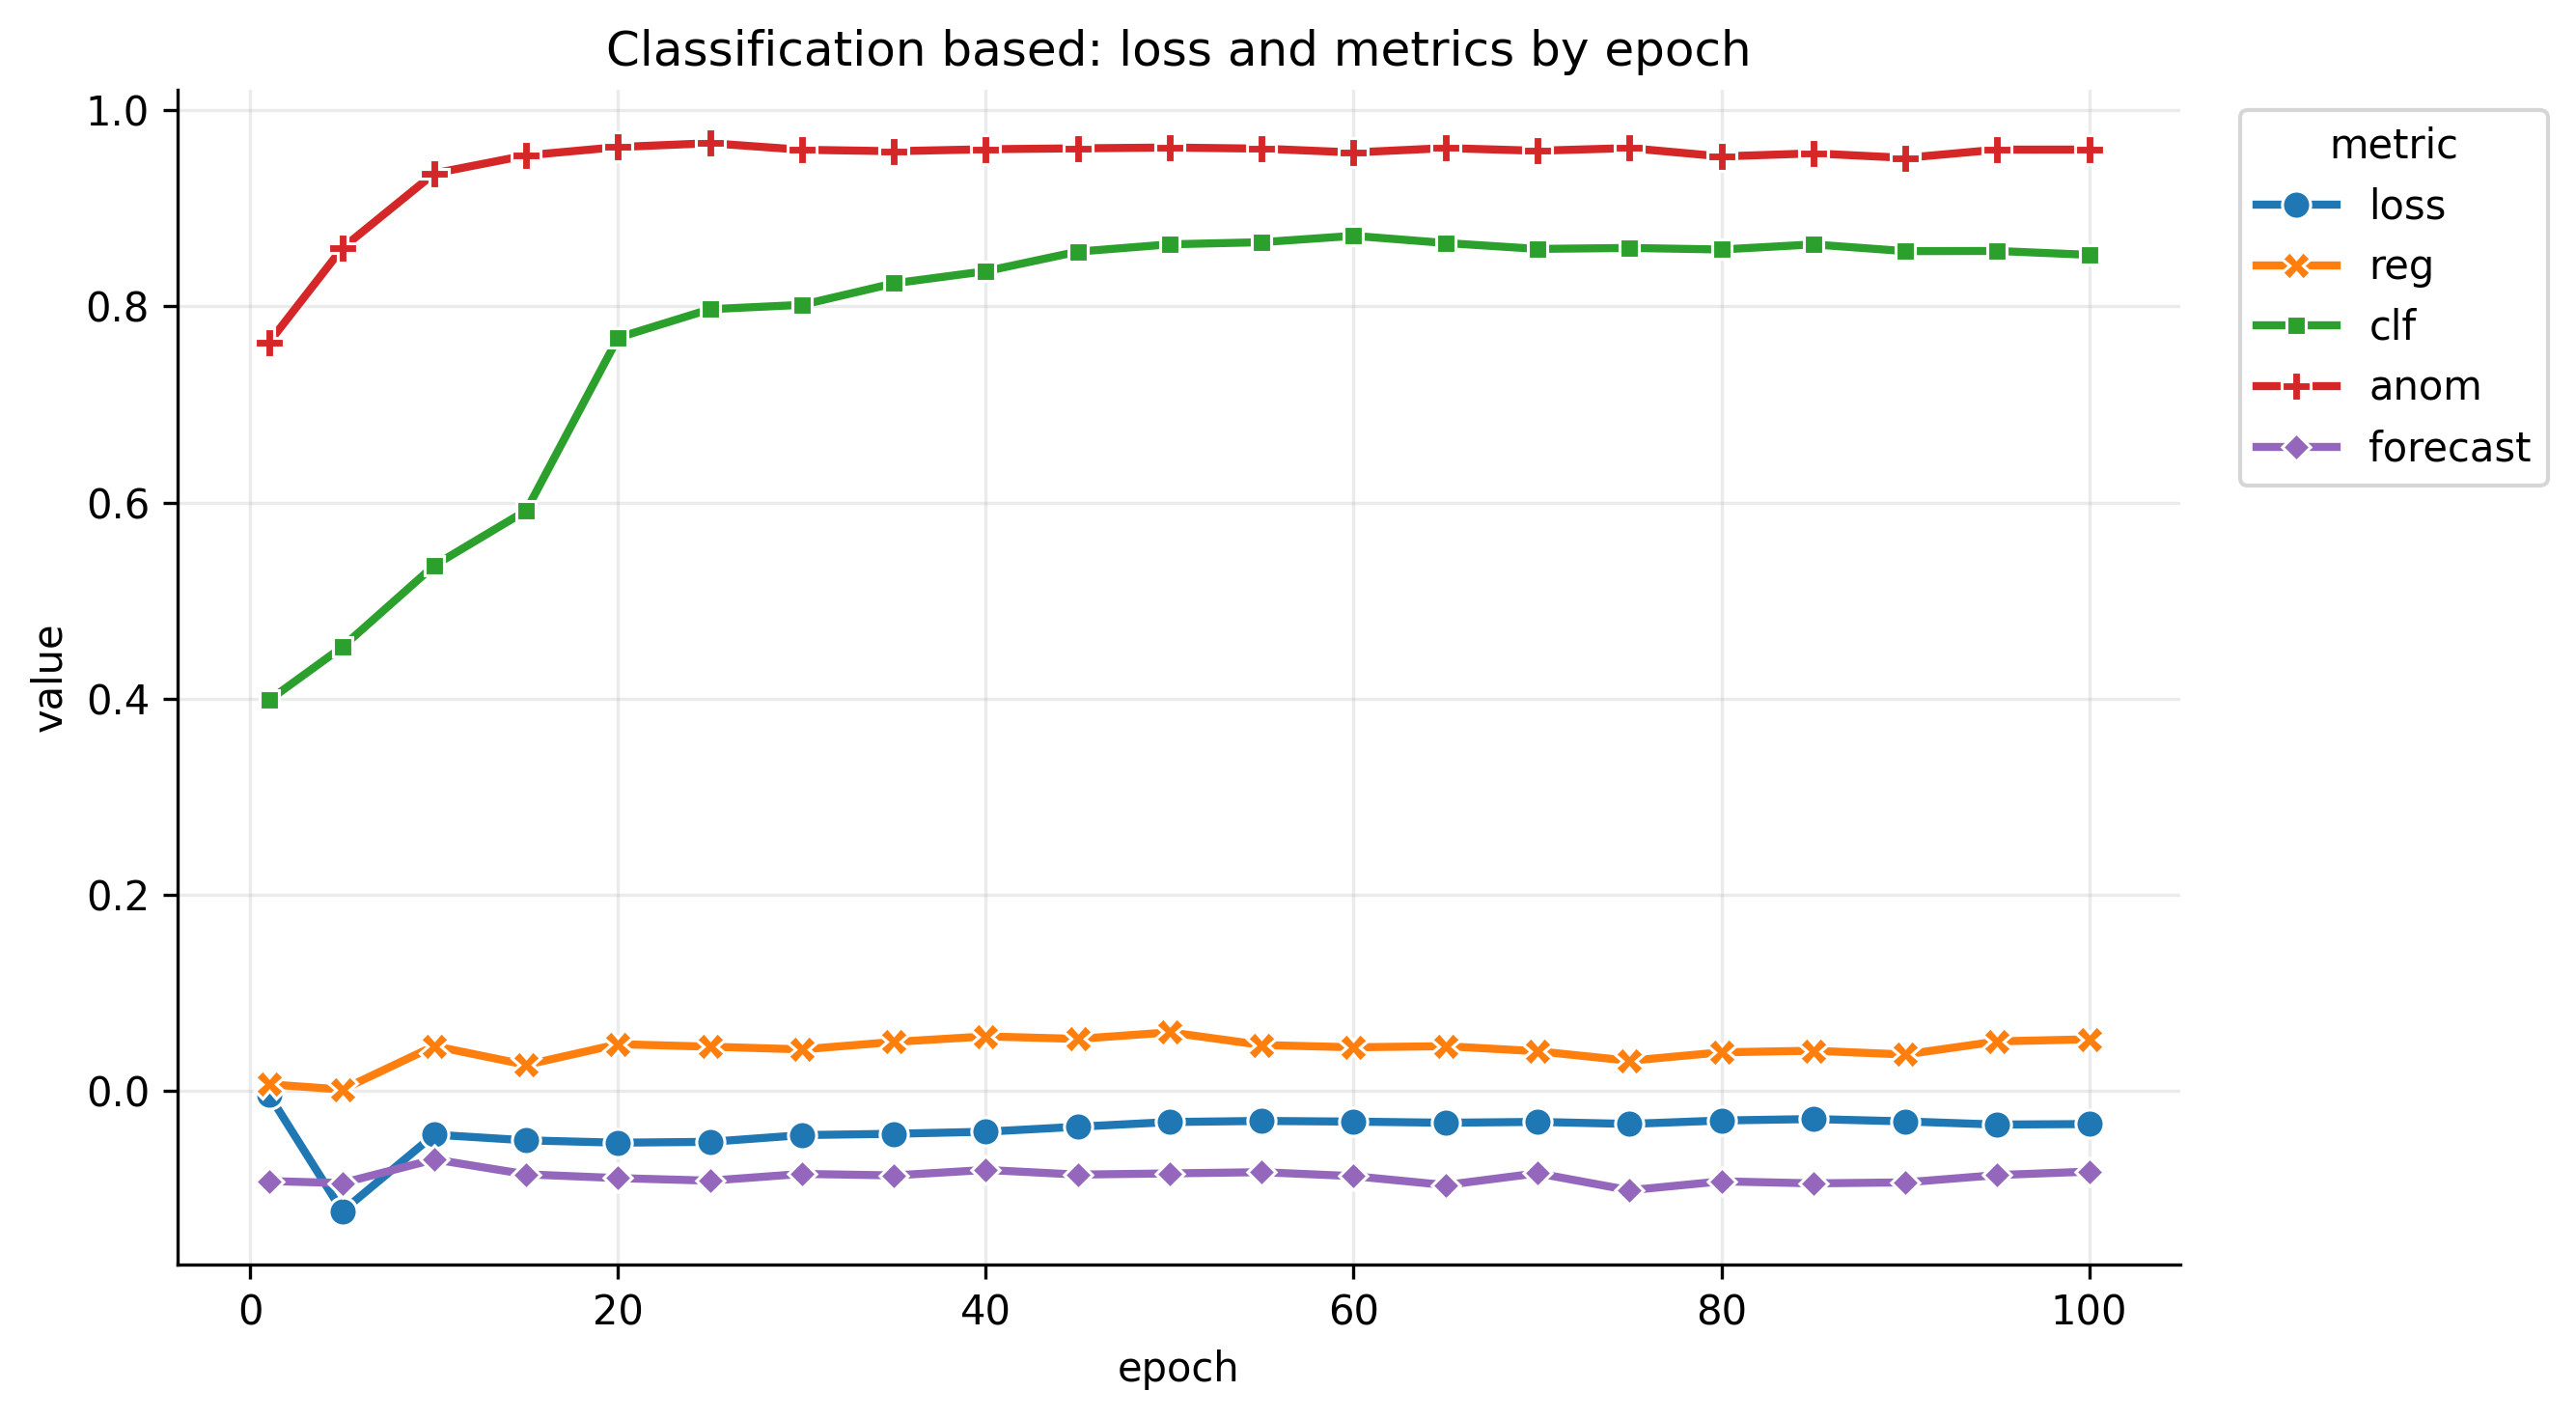

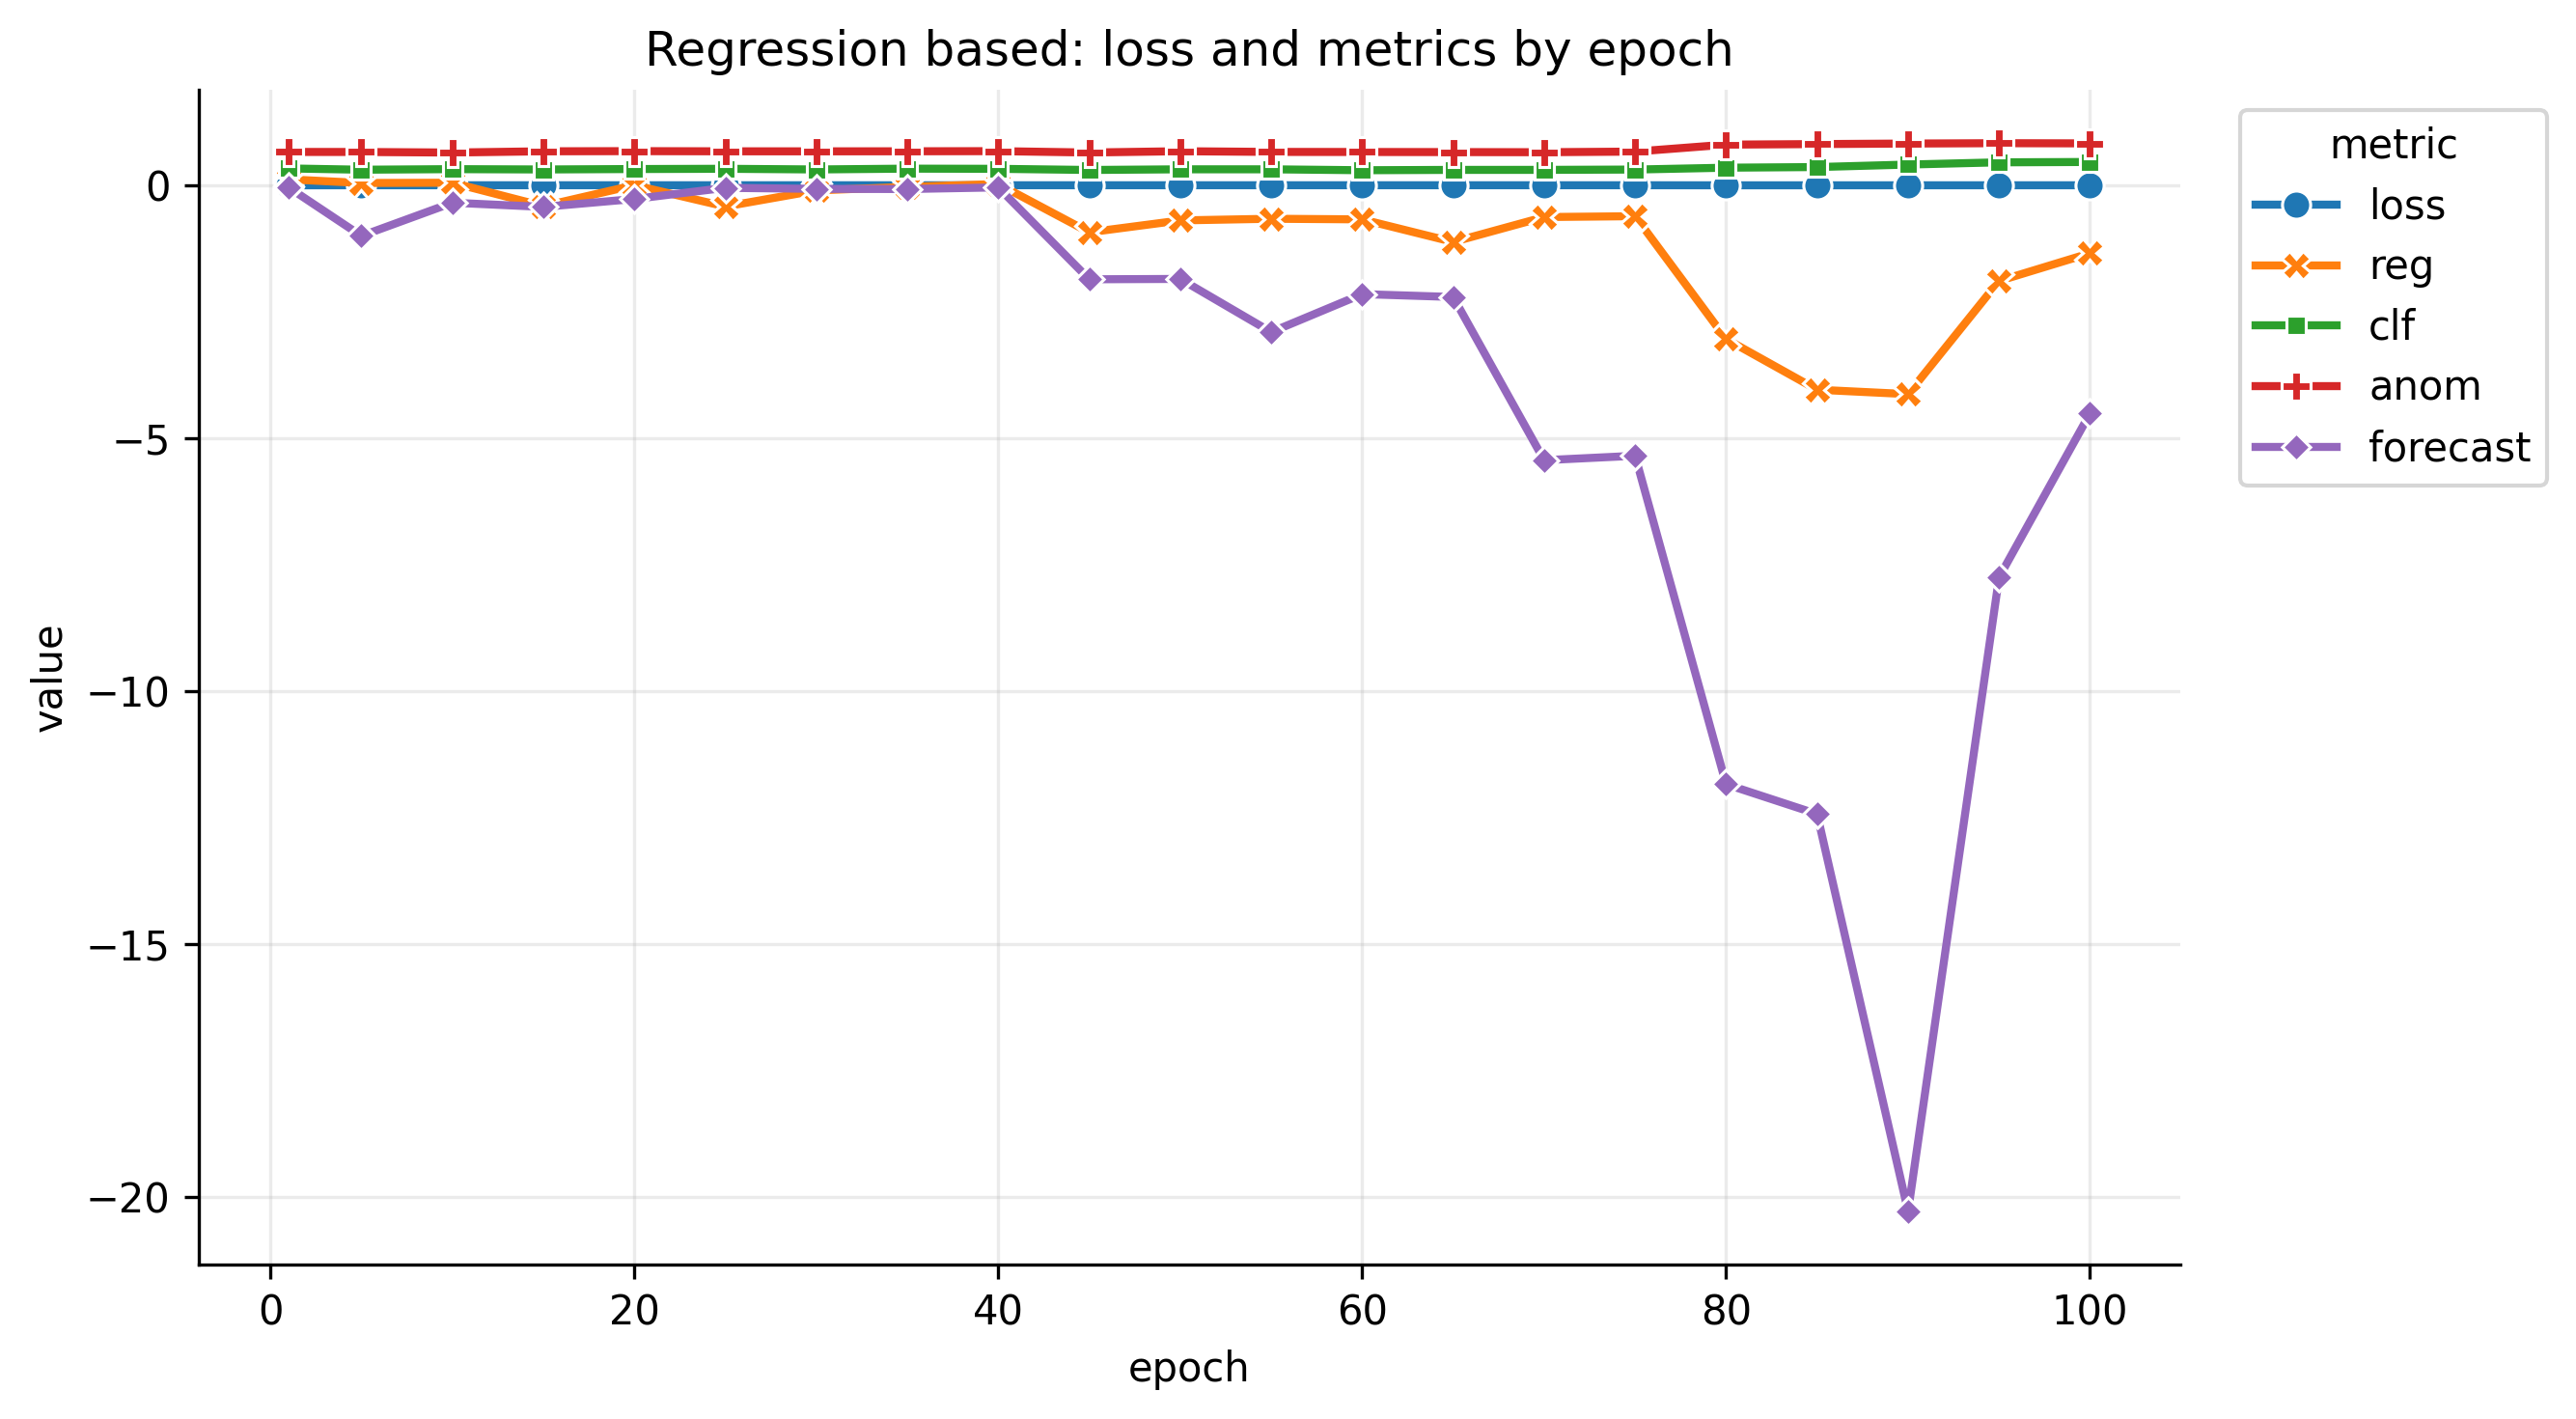

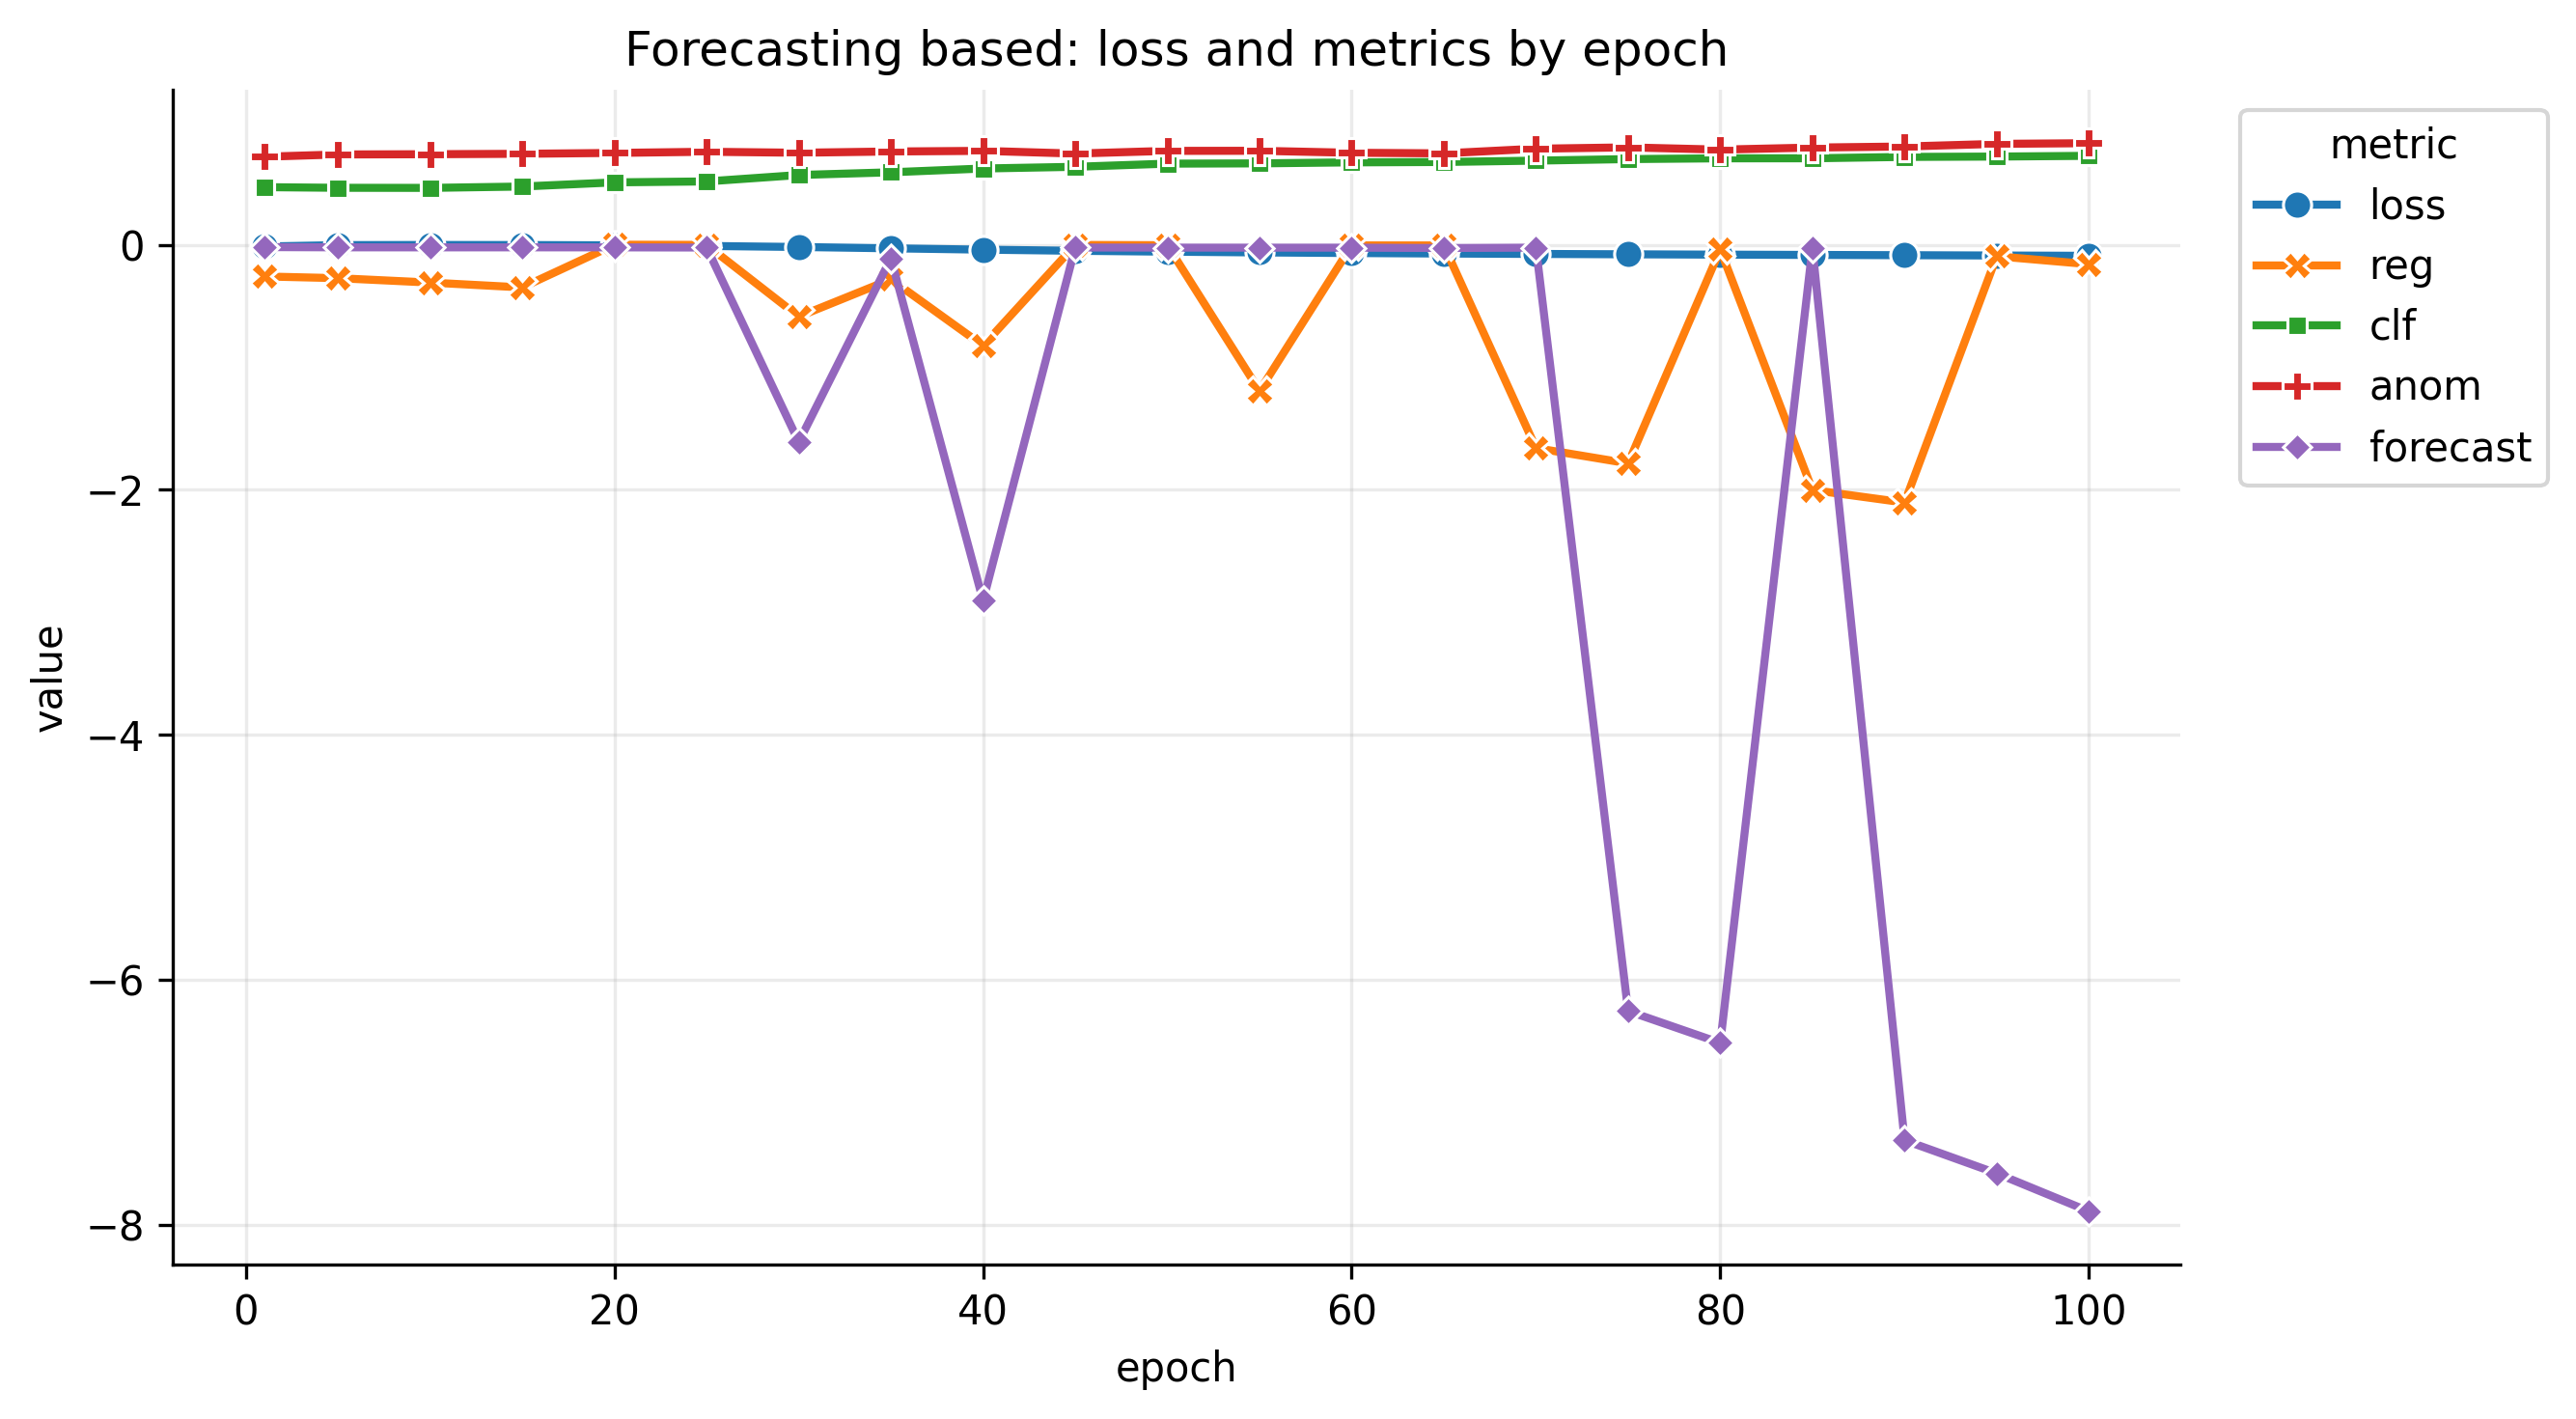

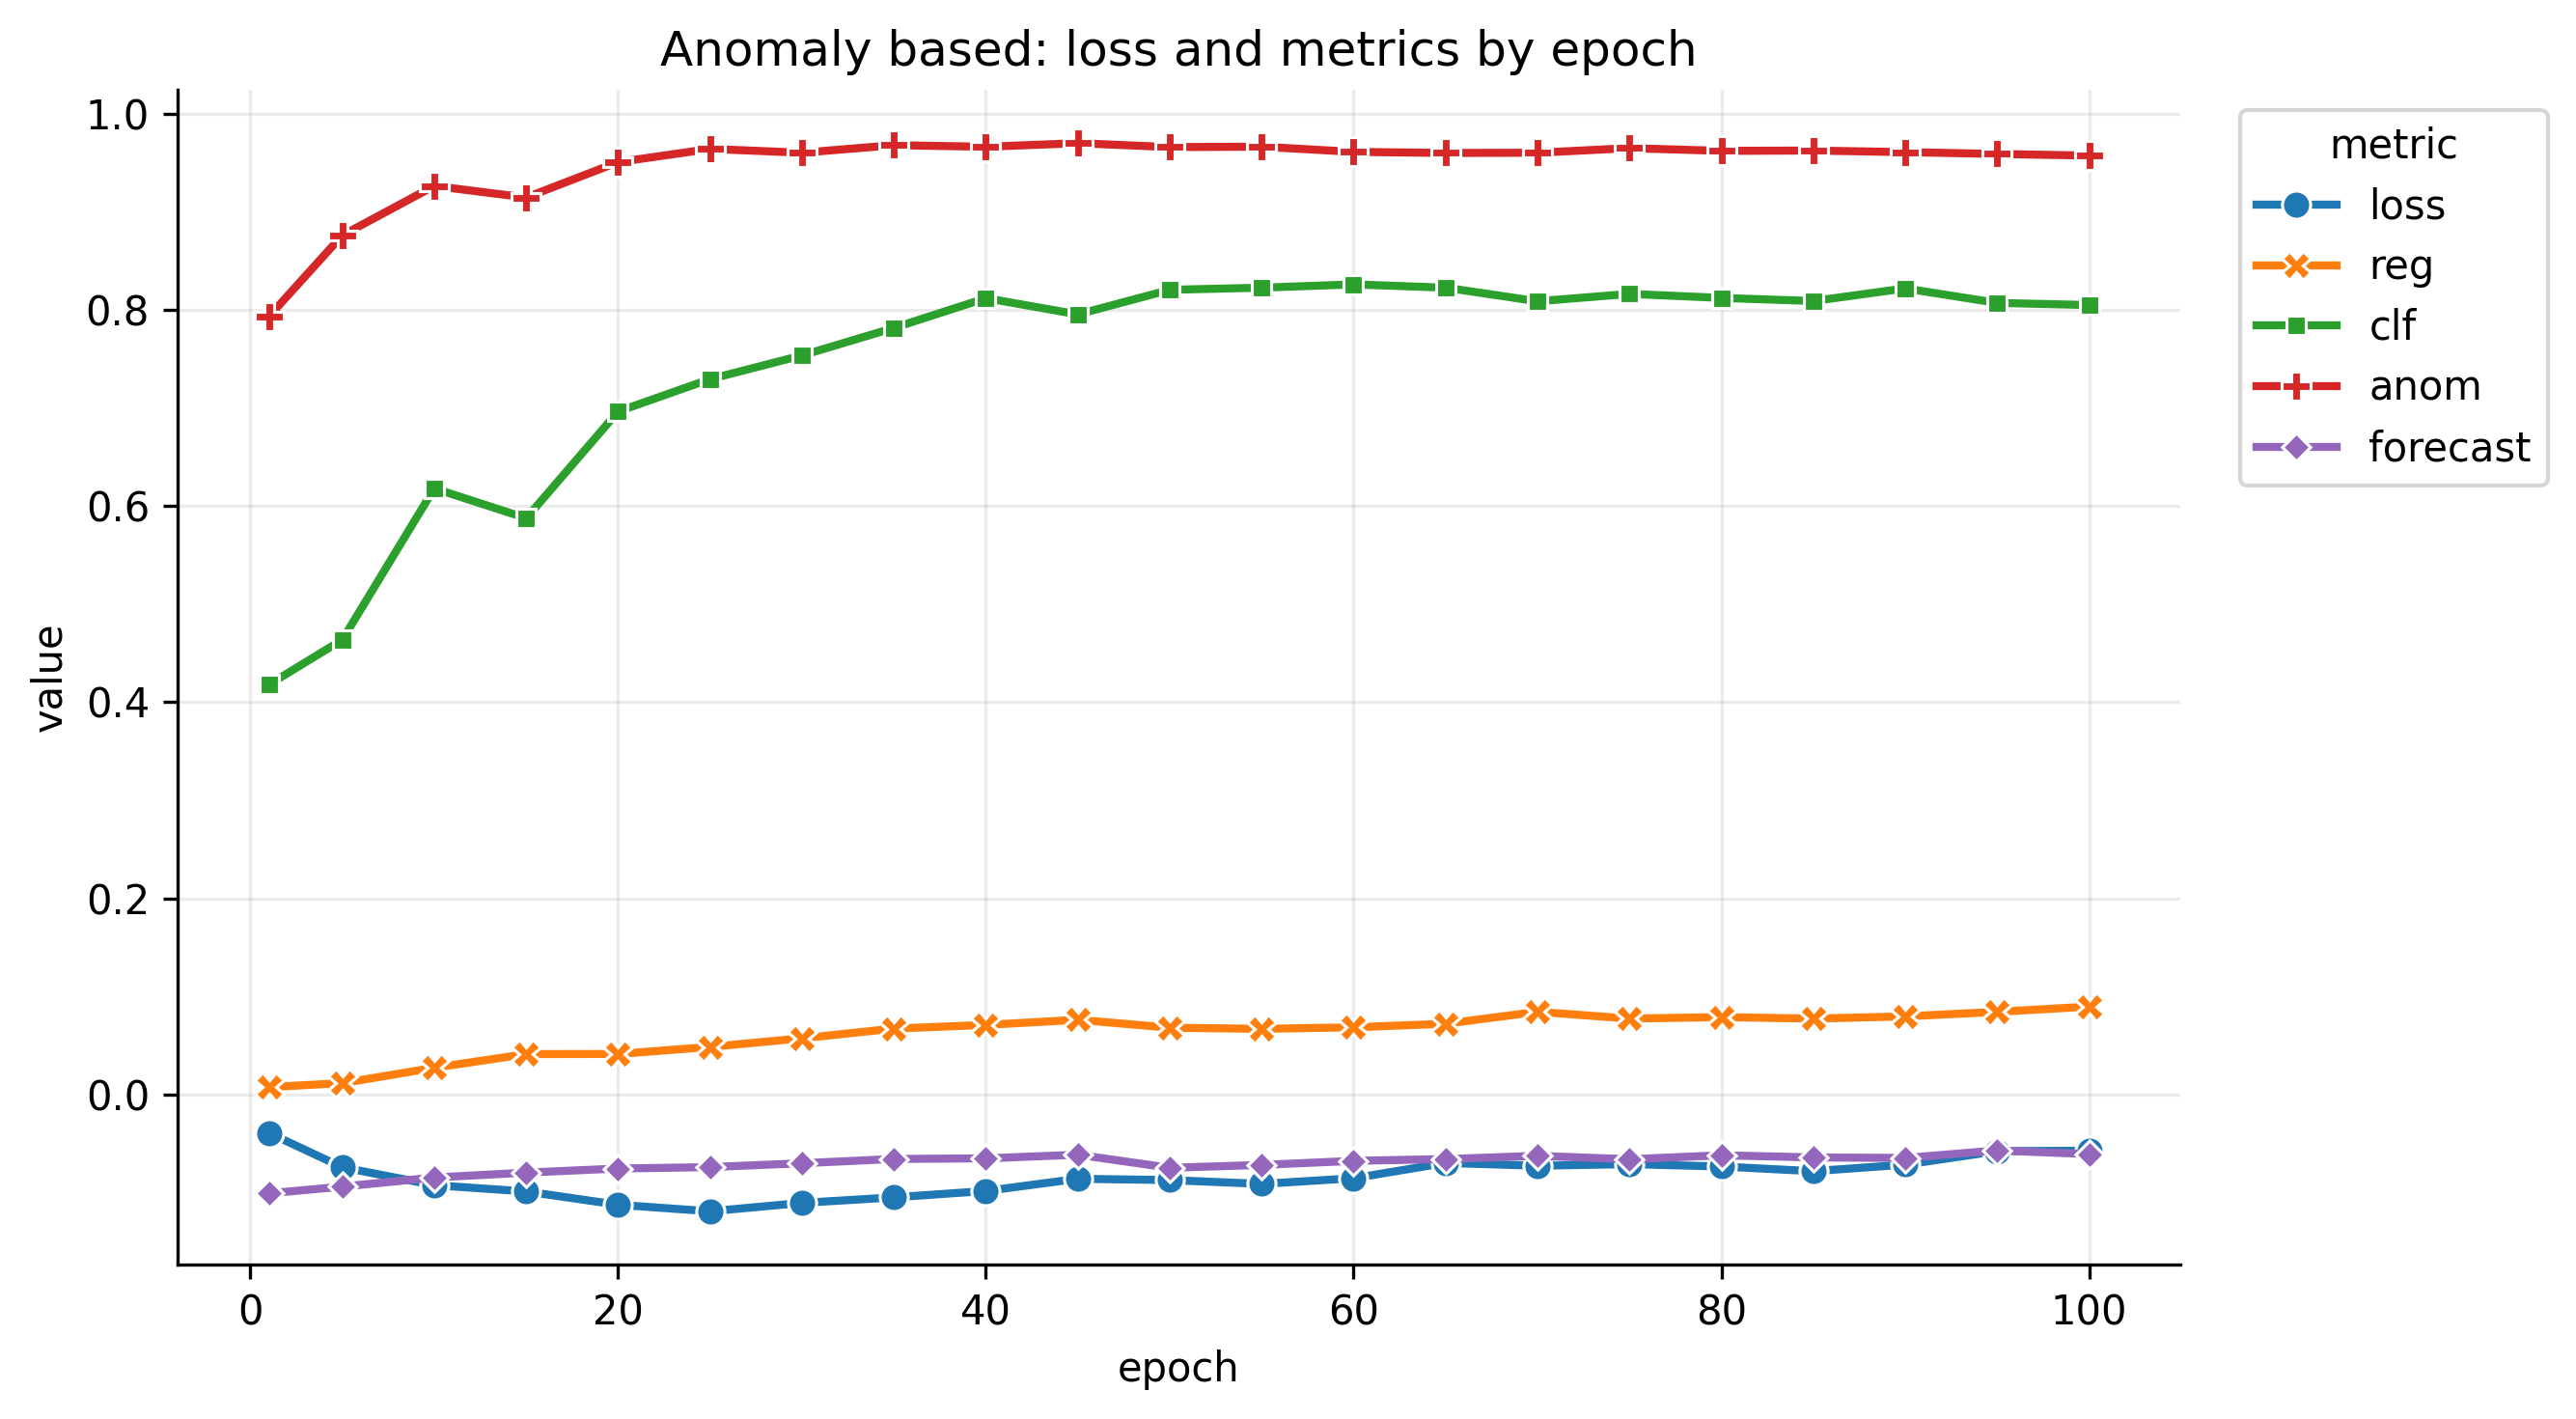

In [ ]:
plot_epoch_metric_points(clean_dfs)

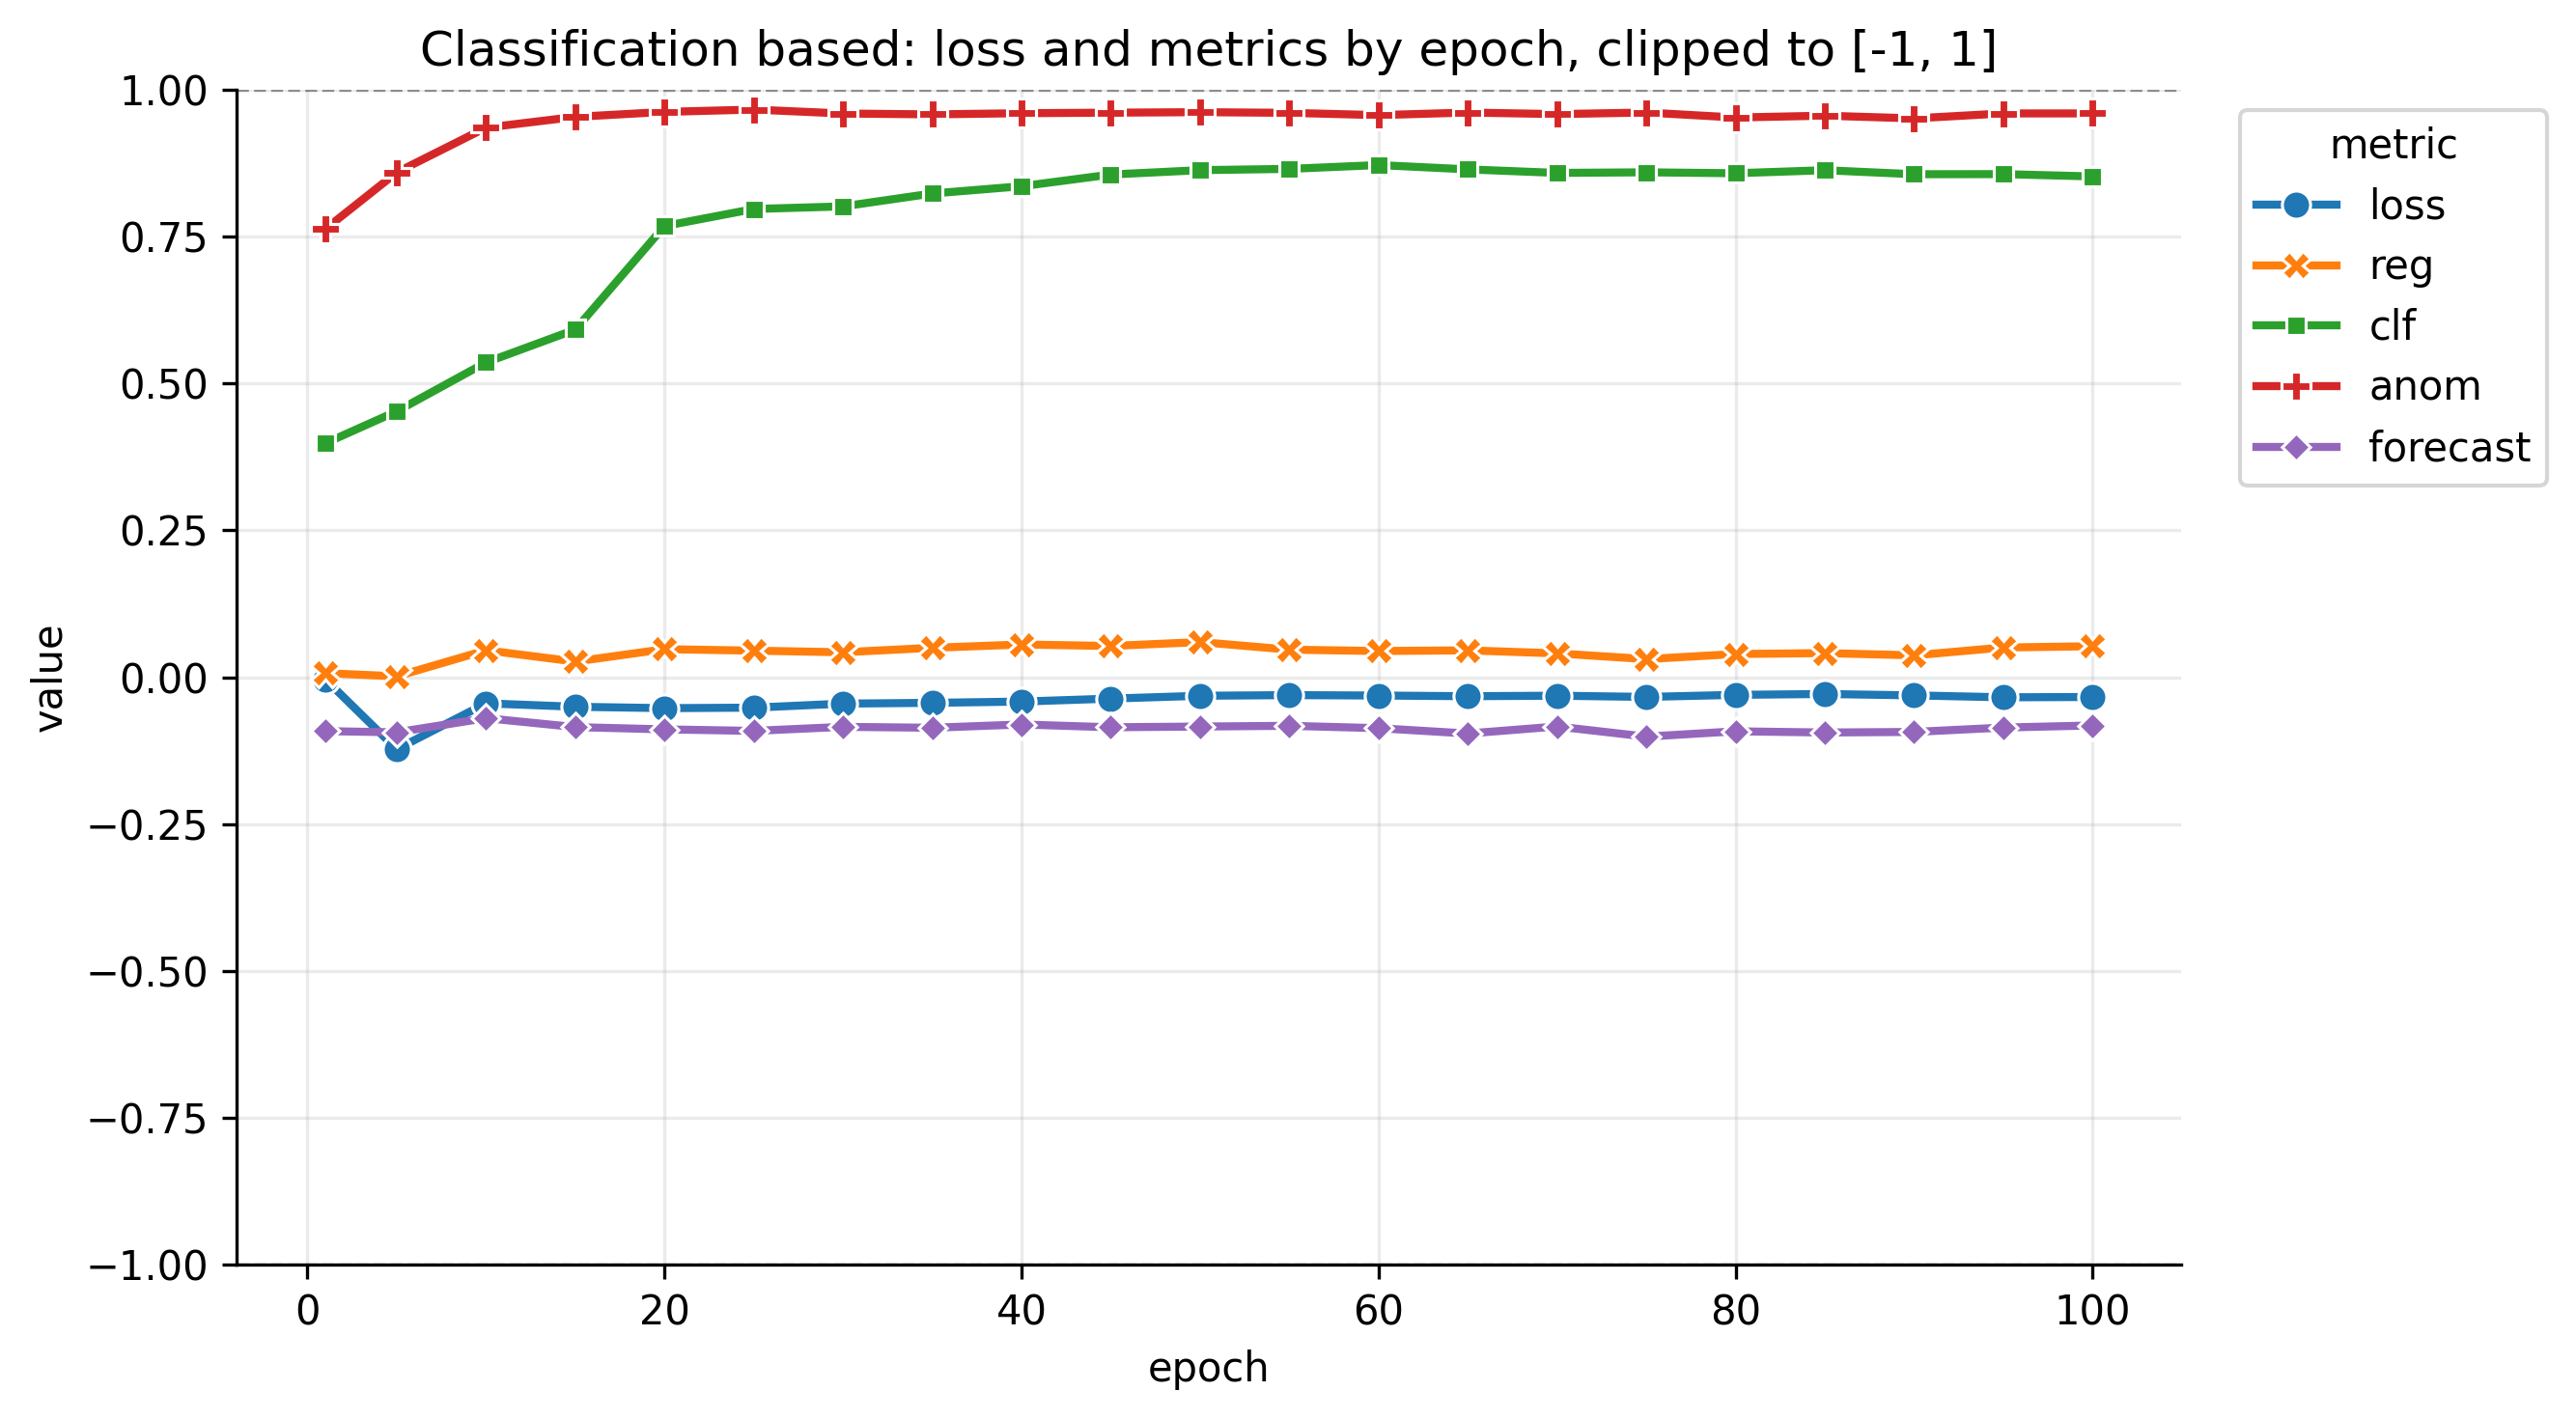

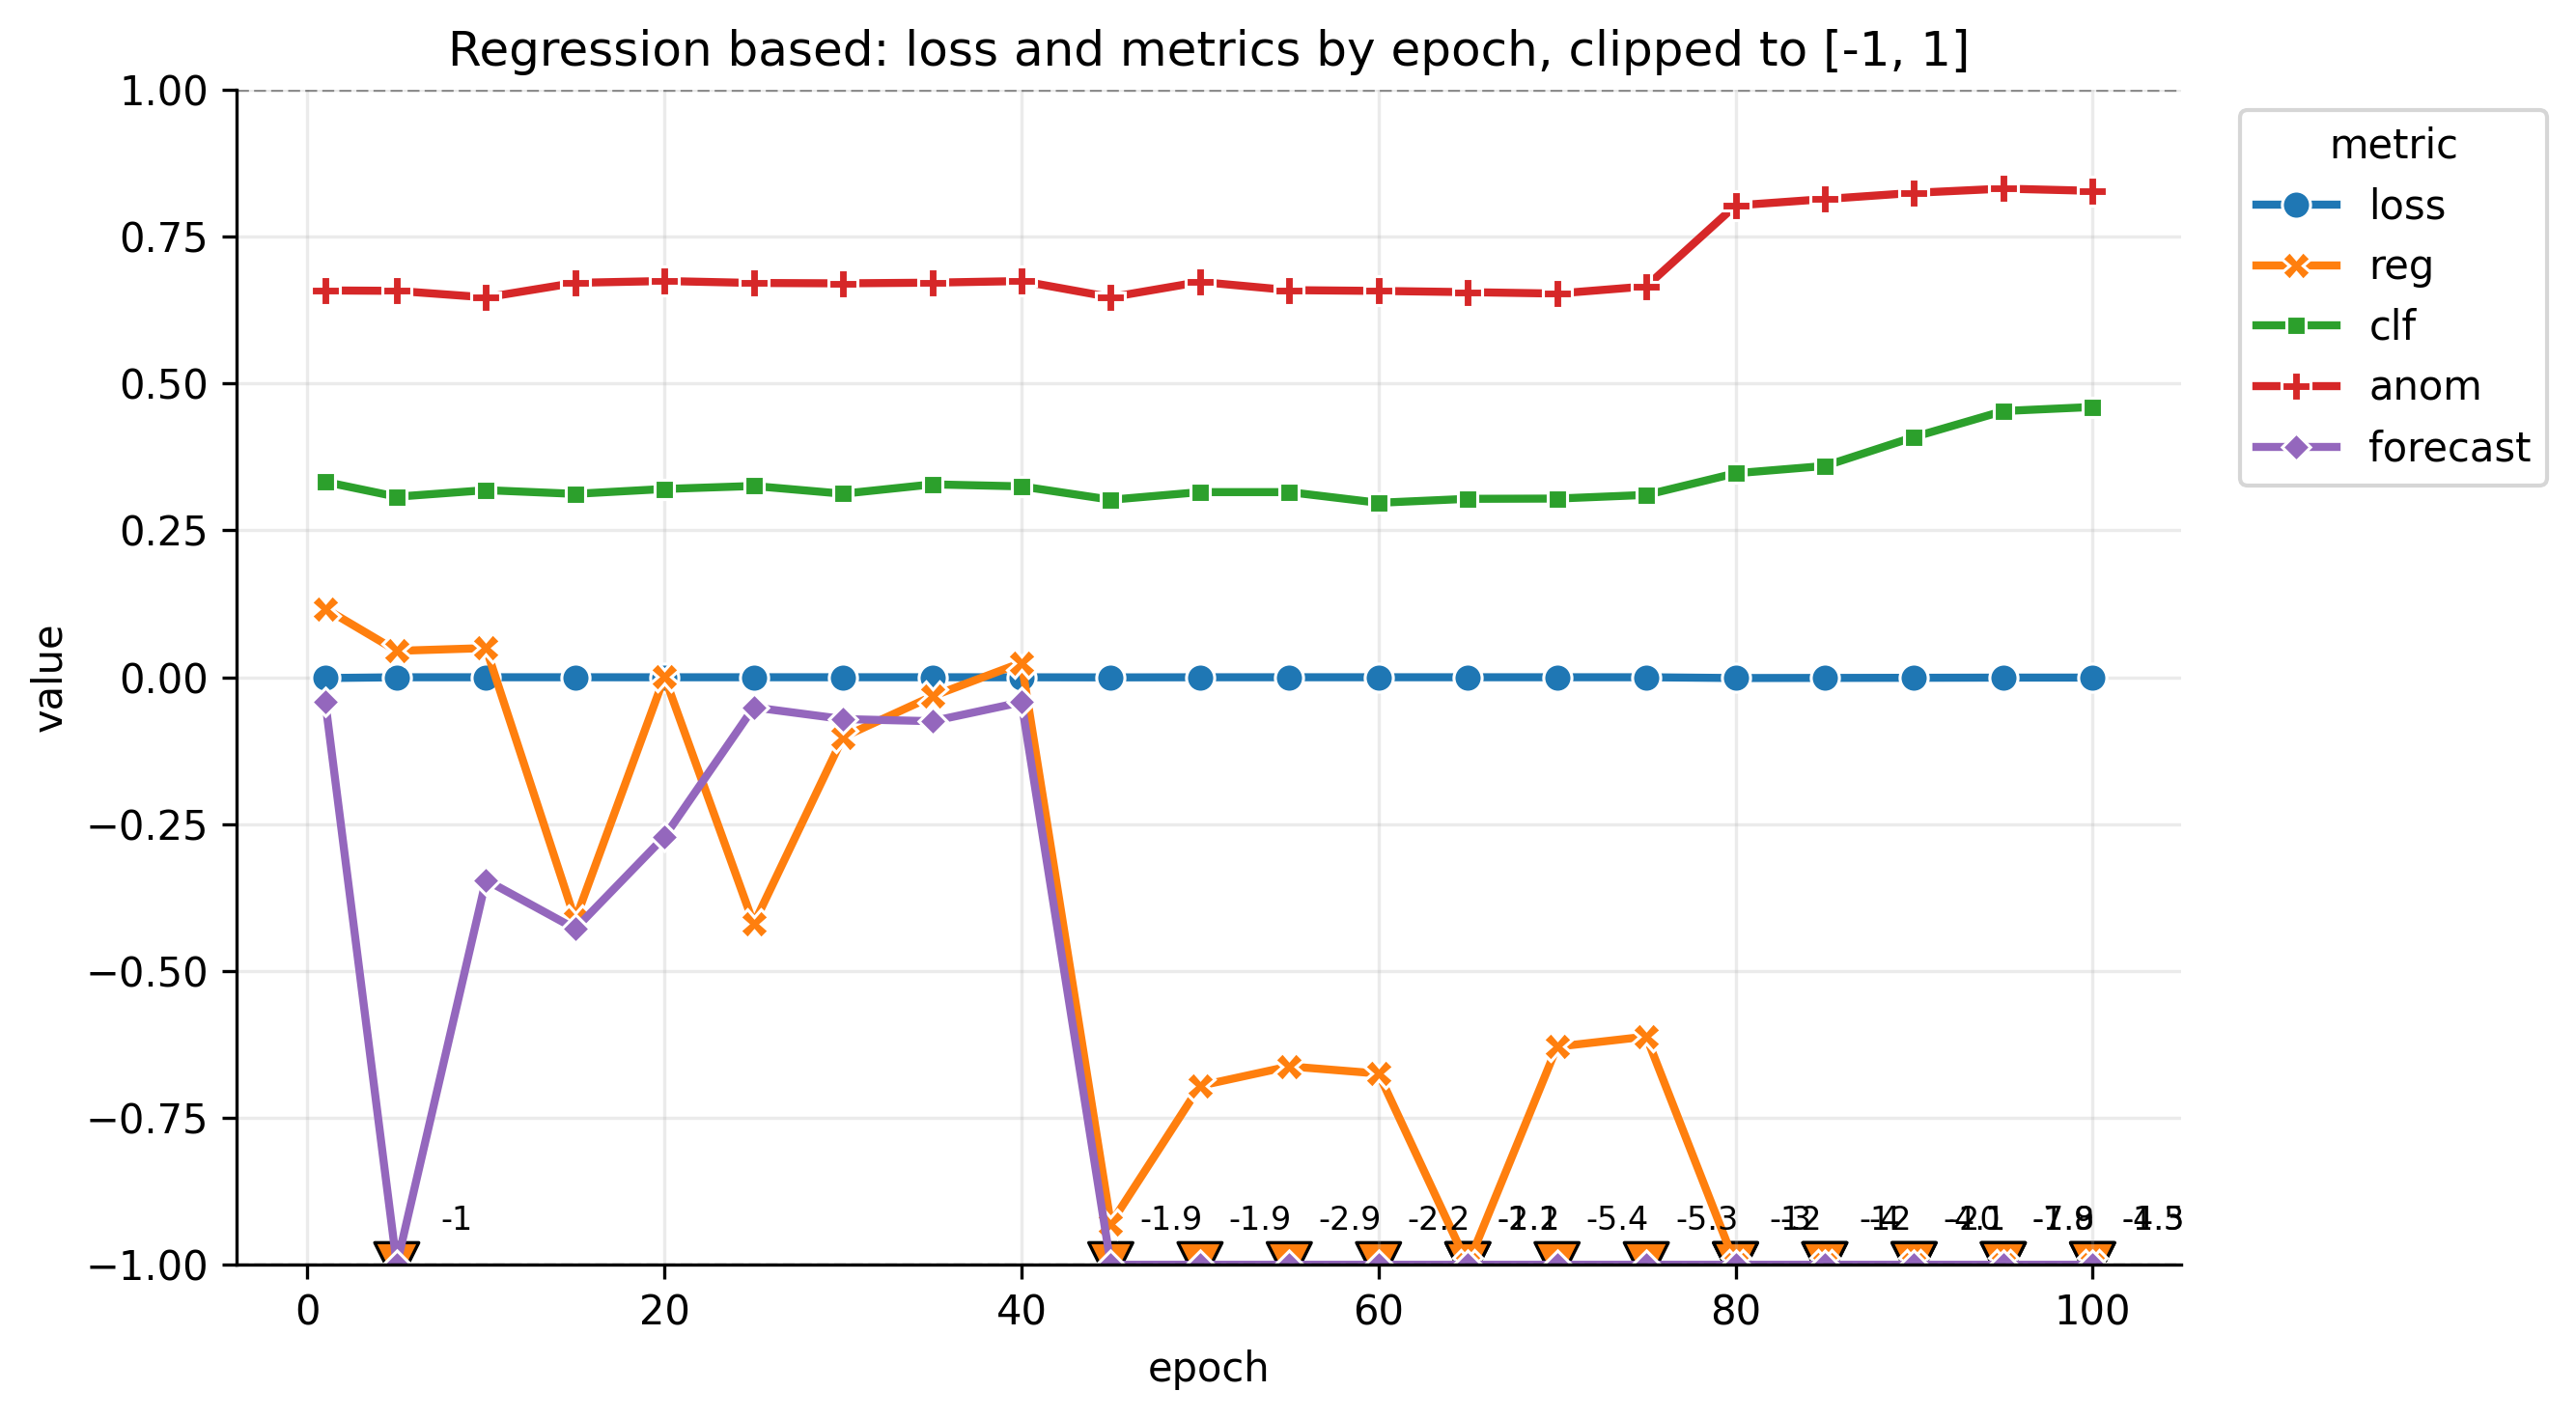

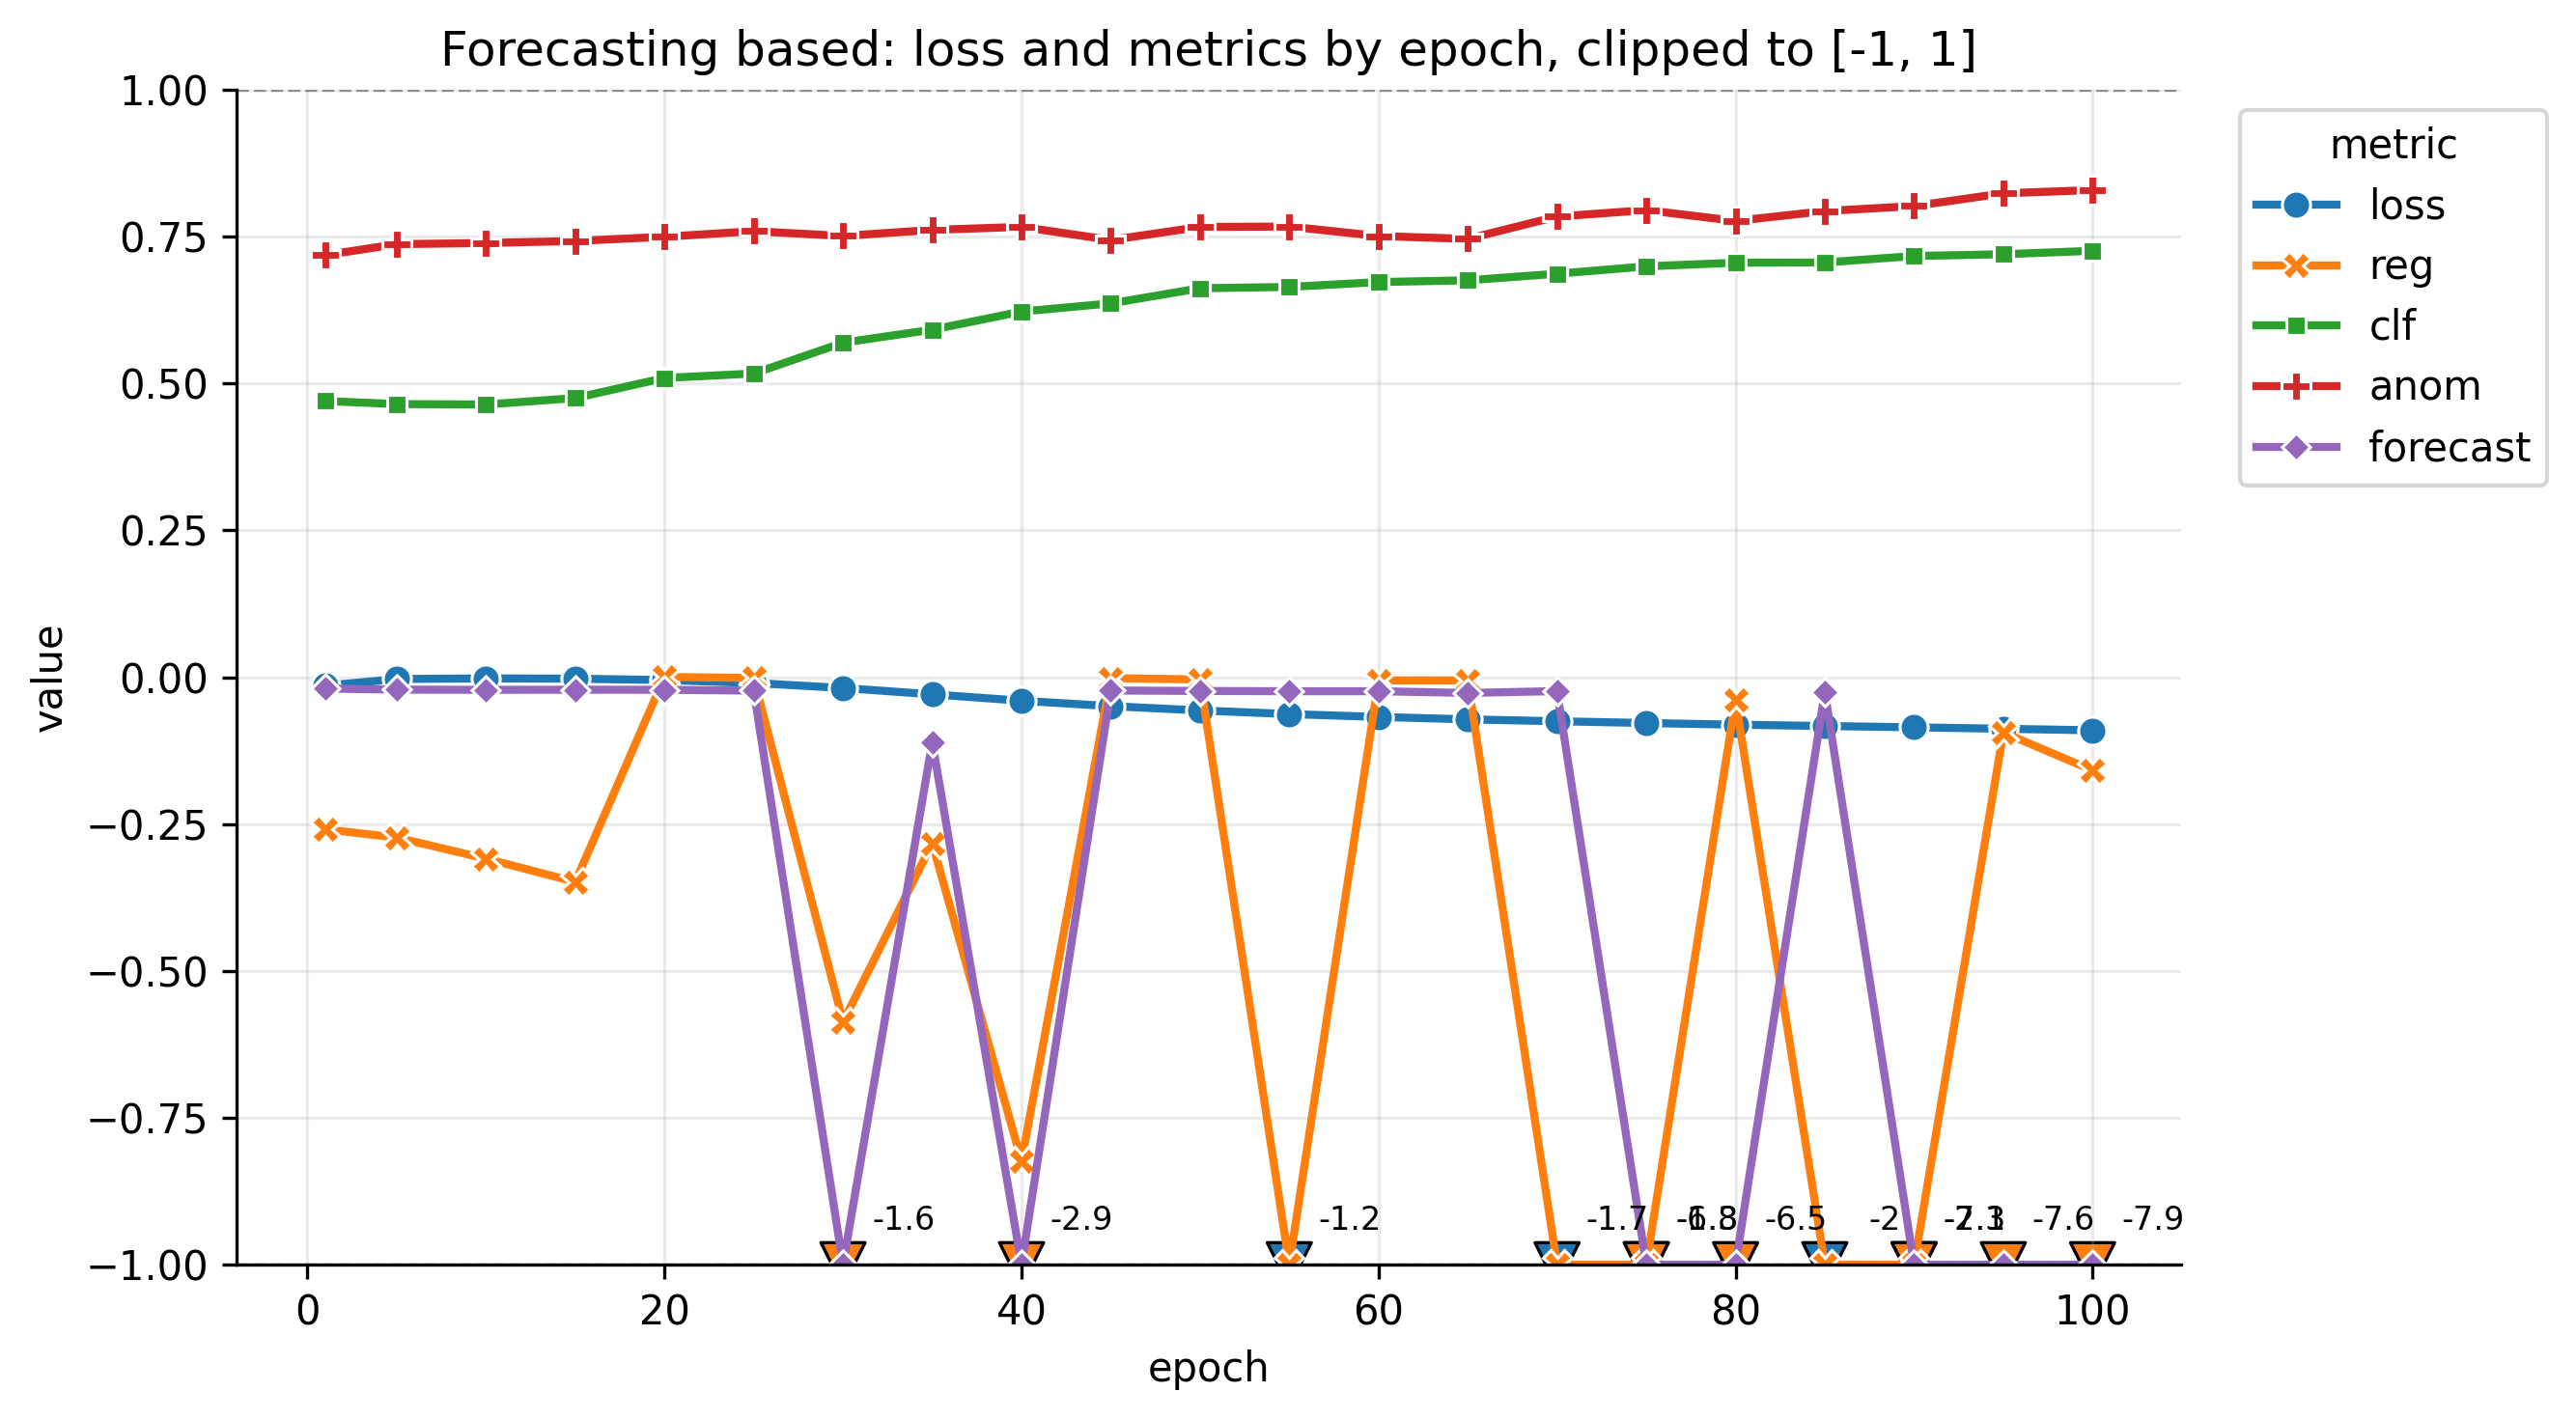

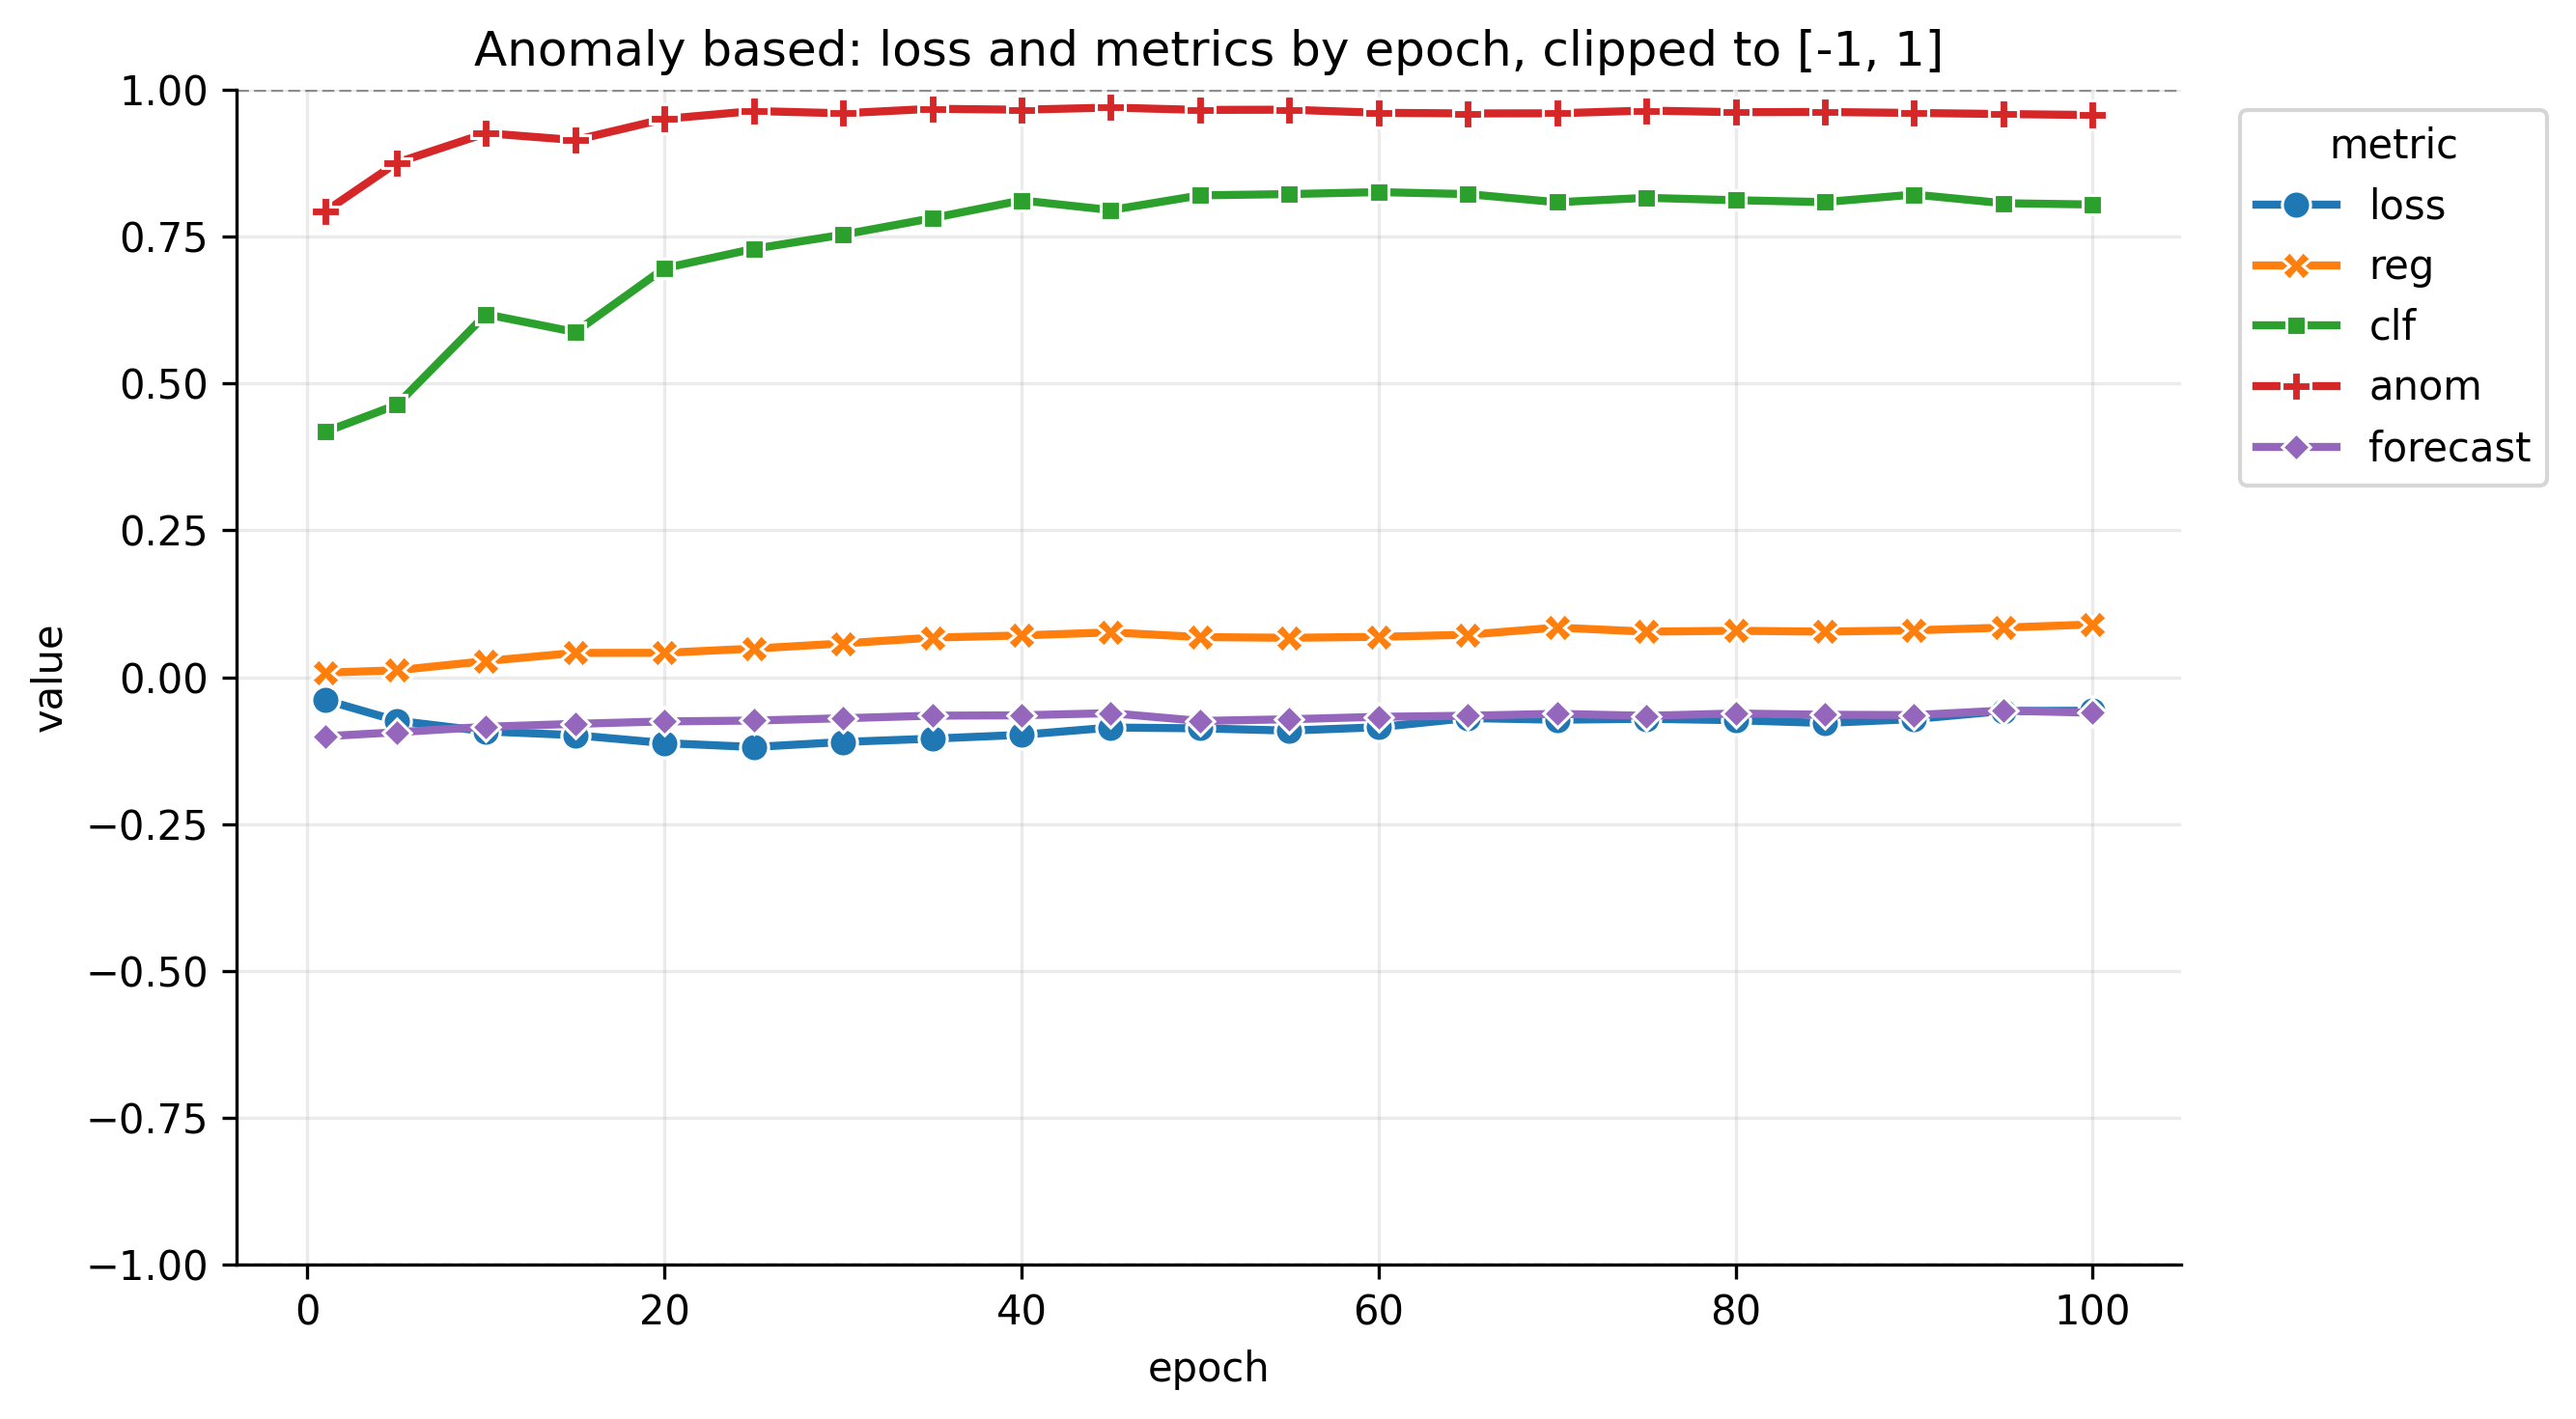

In [16]:
def plot_epoch_metric_points_clipped(clean_dfs, epoch_name="epoch", y_min=-1, y_max=1):
    for title, df in clean_dfs.items():
        plot_df = (
            df
            .rename_axis(epoch_name)
            .reset_index()
            .melt(id_vars=epoch_name, var_name="metric", value_name="value")
            .dropna()
        )
        plot_df["clipped_value"] = plot_df["value"].clip(y_min, y_max)
        plot_df["is_clipped_low"] = plot_df["value"] < y_min
        plot_df["is_clipped_high"] = plot_df["value"] > y_max

        plt.figure(figsize=(9, 5), dpi=300)
        ax = sns.lineplot(
            data=plot_df,
            x=epoch_name,
            y="clipped_value",
            hue="metric",
            style="metric",
            markers=True,
            dashes=False,
            linewidth=2,
            markersize=7,
        )

        clipped_low = plot_df[plot_df["is_clipped_low"]]
        clipped_high = plot_df[plot_df["is_clipped_high"]]

        if not clipped_low.empty:
            sns.scatterplot(
                data=clipped_low,
                x=epoch_name,
                y="clipped_value",
                hue="metric",
                marker="v",
                s=120,
                edgecolor="black",
                linewidth=0.8,
                legend=False,
                ax=ax,
            )

        if not clipped_high.empty:
            sns.scatterplot(
                data=clipped_high,
                x=epoch_name,
                y="clipped_value",
                hue="metric",
                marker="^",
                s=120,
                edgecolor="black",
                linewidth=0.8,
                legend=False,
                ax=ax,
            )

        for _, row in plot_df[plot_df["is_clipped_low"] | plot_df["is_clipped_high"]].iterrows():
            # y_offset = 15 if row["is_clipped_low"] else 10
            va = "top" if row["is_clipped_low"] else "bottom"
            ax.annotate(
                f'{row["value"]:.2g}',
                xy=(row[epoch_name], row["clipped_value"]),
                xytext=(15, 15),
                textcoords="offset points",
                ha="center",
                va=va,
                fontsize=8,
                color="black",
            )

        ax.axhline(y_min, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
        ax.axhline(y_max, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"{title}: loss and metrics by epoch, clipped to [{y_min}, {y_max}]")
        ax.set_xlabel(epoch_name)
        ax.set_ylabel("value")
        # ax.set_yscale('log')
        ax.grid(True, alpha=0.25)
        ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")
        sns.despine()
        plt.tight_layout()
        plt.show()


plot_epoch_metric_points_clipped(clean_dfs, y_min=-1, y_max=1)
